In [ ]:
import json
import os

# Replace with your actual Kaggle username and API key
kaggle_credentials = {
    "username": "anushkabairagi",
    "key": "KGAT_01cfae61032d307b118ea4dae253e245"
}

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(kaggle_credentials, f)

# Set secure permissions
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d bharatkumar0925/walmart-store-sales
!unzip -q walmart-store-sales.zip -d ./data/walmart

Dataset URL: https://www.kaggle.com/datasets/bharatkumar0925/walmart-store-sales
License(s): CC0-1.0
100% 122k/122k [00:00<00:00, 93.3MB/s]



In [ ]:
!kaggle datasets download -d pratyushakar/rossmann-store-sales
!unzip -q rossmann-store-sales.zip -d ./data/rossmann

Dataset URL: https://www.kaggle.com/datasets/pratyushakar/rossmann-store-sales
License(s): CC0-1.0
100% 6.90M/6.90M [00:00<00:00, 108MB/s]



In [ ]:
!kaggle datasets download -d psparks/instacart-market-basket-analysis
!unzip -q instacart-market-basket-analysis.zip -d ./data/instacart

Dataset URL: https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis
License(s): CC0-1.0
instacart-market-basket-analysis.zip: Skipping, found more recently modified local copy (use --force to force download)
replace ./data/instacart/aisles.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ./data/instacart/departments.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ./data/instacart/order_products__prior.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ./data/instacart/order_products__train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ./data/instacart/orders.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ./data/instacart/products.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
!kaggle datasets download -d ziya07/high-dimensional-supply-chain-inventory-dataset
!unzip -q high-dimensional-supply-chain-inventory-dataset.zip -d ./data/supply_chainn

Dataset URL: https://www.kaggle.com/datasets/ziya07/high-dimensional-supply-chain-inventory-dataset
License(s): CC0-1.0
high-dimensional-supply-chain-inventory-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace ./data/supply_chain/supply_chain_dataset1.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
import os

for root, dirs, files in os.walk("data"):
    for file in files:
        print(os.path.join(root, file))

data/supply_chain_dataset1.csv
data/retail_store_inventory.csv
data/instacart/aisles.csv
data/instacart/orders.csv
data/instacart/order_products__train.csv
data/instacart/products.csv
data/instacart/order_products__prior.csv
data/instacart/departments.csv
data/walmart/Walmart_Store_sales.csv
data/rossmann/train.csv
data/rossmann/test.csv
data/rossmann/store.csv
data/supply_chain/supply_chain_dataset1.csv


# ***Walmart ML Demand Forecasting***:

├── 1. Data Loading

├── 2. Data Cleaning

├── 3. Basic EDA

├── 4. Prepare data for Feature Engineering

├── 5. Date feature

├── 6. Lag

├── 7. Rolling

├── 8. Seasonal

├── 9. Time-Based Train/Test

├── 10. Random

├── 11. Gradient

├── 12. Model Evaluation

│     ├── MAE

│     ├── RMSE

│     ├── MAPE

│     └── R²

├── 13. Best Model Selection

├── 14. Future Demand Prediction

└── 15. Visualization & Business Insights



*   Target: sales / demand
*   Models: Random Forest + Gradient Boosting
*   Evaluation: MAE, RMSE, MAPE, R²
*   Final: Future demand prediction








In [ ]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ==========================================
# LOAD DATASETS
# ==========================================

walmart_sales_df = pd.read_csv("data/walmart/Walmart_Store_sales.csv")

print("Walmart Sales shape:", walmart_sales_df.shape)

display(walmart_sales_df.head())

Walmart Sales shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
# sell_prices_df = pd.read_csv("sell_prices.csv")

In [ ]:
# ==========================================
# 2. DATA CLEANING
# ==========================================

print("Missing values in Walmart sales:")
print(walmart_sales_df.isnull().sum())

Missing values in Walmart sales:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [ ]:
# Remove duplicate rows

walmart_sales_df = walmart_sales_df.drop_duplicates()

print("Walmart Sales shape after duplicates:", walmart_sales_df.shape)

Walmart Sales shape after duplicates: (6435, 8)


In [ ]:
# Identify day columns

day_columns = [col for col in walmart_sales_df.columns if col.startswith("d_")]

print("Number of sales days:", len(day_columns))
print(day_columns[:10])

Number of sales days: 0
[]


In [ ]:
# ==========================================
# 3. BASIC EDA
# ==========================================

# The 'Weekly_Sales' column contains the sales data for this dataset.
weekly_sales = walmart_sales_df["Weekly_Sales"]

print("Weekly Sales Head:\n", weekly_sales.head())
print("\nTotal demand:", weekly_sales.sum())
print("Average weekly demand:", weekly_sales.mean())

Weekly Sales Head:
 0    1643690.90
1    1641957.44
2    1611968.17
3    1409727.59
4    1554806.68
Name: Weekly_Sales, dtype: float64

Total demand: 6737218987.11
Average weekly demand: 1046964.8775617715


In [ ]:
# Create a DataFrame for weekly sales with proper date handling
weekly_sales_df = walmart_sales_df[["Date", "Weekly_Sales"]].copy()
weekly_sales_df["Date"] = pd.to_datetime(weekly_sales_df["Date"], format="%d-%m-%Y")
weekly_sales_df = weekly_sales_df.sort_values("Date")

print("Weekly Sales DataFrame Head:\n", weekly_sales_df.head())

Weekly Sales DataFrame Head:
            Date  Weekly_Sales
0    2010-02-05    1643690.90
1287 2010-02-05    2193048.75
5148 2010-02-05     536006.73
2288 2010-02-05     789036.02
4147 2010-02-05     465108.52


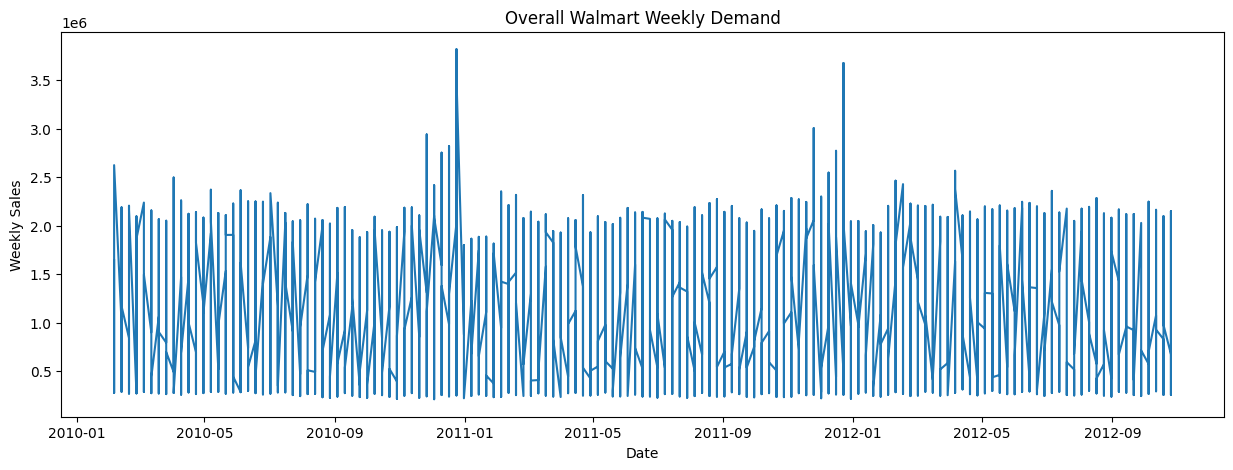

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    weekly_sales_df["Date"],
    weekly_sales_df["Weekly_Sales"]
)

plt.title("Overall Walmart Weekly Demand")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.show()

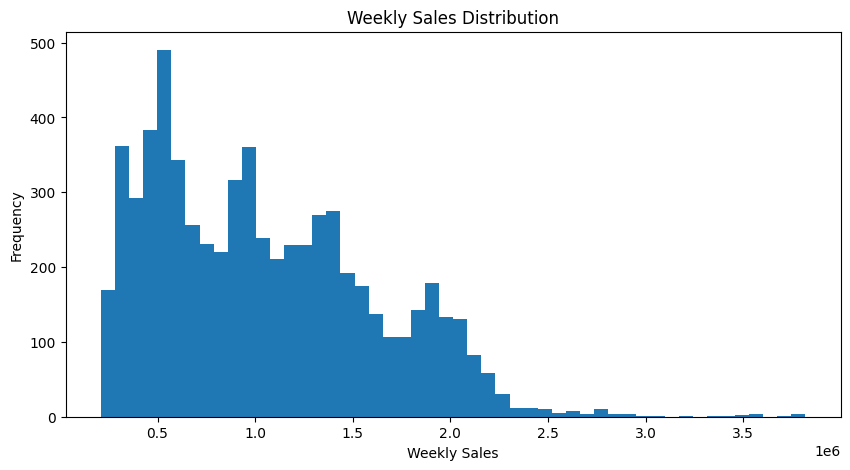

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(weekly_sales_df["Weekly_Sales"], bins=50)

plt.title("Weekly Sales Distribution")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# ==========================================
# 4. PREPARE DATA FOR FEATURE ENGINEERING
# ==========================================

sales_long = walmart_sales_df.copy()
sales_long = sales_long.rename(columns={
    "Store": "id",
    "Date": "date",
    "Weekly_Sales": "sales"
})

sales_long["date"] = pd.to_datetime(sales_long["date"], format="%d-%m-%Y")

# Select relevant columns for sales_long to maintain consistency with previous steps
sales_long = sales_long[[
    "id",
    "date",
    "sales",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]]

print("Sales Long shape:", sales_long.shape)
display(sales_long.head())

Sales Long shape: (6435, 8)


,id,date,sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
# ==========================================
# 5. DATE FEATURES
# ==========================================

sales_long["year"] = sales_long["date"].dt.year
sales_long["month"] = sales_long["date"].dt.month
sales_long["day"] = sales_long["date"].dt.day
sales_long["day_of_week"] = sales_long["date"].dt.dayofweek
sales_long["week_of_year"] = sales_long["date"].dt.isocalendar().week.astype(int)
sales_long["quarter"] = sales_long["date"].dt.quarter

sales_long["is_weekend"] = (
    sales_long["day_of_week"] >= 5
).astype(int)

In [ ]:
sales_long[
    [
        "date",
        "year",
        "month",
        "day",
        "day_of_week",
        "week_of_year",
        "quarter",
        "is_weekend"
    ]
].head()

,date,year,month,day,day_of_week,week_of_year,quarter,is_weekend
28,2010-08-20,2010,8,20,4,33,3,0
2745,2010-08-20,2010,8,20,4,33,3,0
1887,2010-08-20,2010,8,20,4,33,3,0
4604,2010-08-20,2010,8,20,4,33,3,0
743,2010-08-20,2010,8,20,4,33,3,0


In [ ]:
# ==========================================
# 6. LAG FEATURES
# ==========================================

sales_long = sales_long.sort_values(
    ["id", "date"]
)

group = sales_long.groupby("id")["sales"]

sales_long["lag_1"] = group.shift(1)
sales_long["lag_7"] = group.shift(7)
sales_long["lag_14"] = group.shift(14)
sales_long["lag_28"] = group.shift(28)

In [ ]:
sales_long[
    [
        "id",
        "date",
        "sales",
        "lag_1",
        "lag_7",
        "lag_14",
        "lag_28"
    ]
].head(40)

,id,date,sales,lag_1,lag_7,lag_14,lag_28
0,1,2010-02-05,1643690.90,NaN,NaN,NaN,NaN
1,1,2010-02-12,1641957.44,1643690.90,NaN,NaN,NaN
2,1,2010-02-19,1611968.17,1641957.44,NaN,NaN,NaN
3,1,2010-02-26,1409727.59,1611968.17,NaN,NaN,NaN
4,1,2010-03-05,1554806.68,1409727.59,NaN,NaN,NaN
5,1,2010-03-12,1439541.59,1554806.68,NaN,NaN,NaN
6,1,2010-03-19,1472515.79,1439541.59,NaN,NaN,NaN
7,1,2010-03-26,1404429.92,1472515.79,1643690.90,NaN,NaN
8,1,2010-04-02,1594968.28,1404429.92,1641957.44,NaN,NaN
9,1,2010-04-09,1545418.53,1594968.28,1611968.17,NaN,NaN


In [ ]:
# ==========================================
# 7. ROLLING FEATURES
# ==========================================

sales_long["rolling_mean_7"] = (
    sales_long.groupby("id")["sales"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

sales_long["rolling_mean_14"] = (
    sales_long.groupby("id")["sales"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

sales_long["rolling_mean_28"] = (
    sales_long.groupby("id")["sales"]
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

In [ ]:
sales_long["rolling_std_7"] = (
    sales_long.groupby("id")["sales"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

sales_long["rolling_std_28"] = (
    sales_long.groupby("id")["sales"]
    .transform(lambda x: x.shift(1).rolling(28).std())
)

In [ ]:
# ==========================================
# 8. SEASONAL FEATURES
# ==========================================

sales_long["month_sin"] = np.sin(
    2 * np.pi * sales_long["month"] / 12
)

sales_long["month_cos"] = np.cos(
    2 * np.pi * sales_long["month"] / 12
)

sales_long["dow_sin"] = np.sin(
    2 * np.pi * sales_long["day_of_week"] / 7
)

sales_long["dow_cos"] = np.cos(
    2 * np.pi * sales_long["day_of_week"] / 7
)

In [ ]:
# Calendar event indicators

if "event_name_1" in sales_long.columns:

    sales_long["has_event"] = (
        sales_long["event_name_1"].notna()
    ).astype(int)

else:

    sales_long["has_event"] = 0

In [ ]:
# ==========================================
# 9. REMOVE ROWS WITH MISSING FEATURES
# ==========================================

sales_long = sales_long.dropna(
    subset=[
        "lag_1",
        "lag_7",
        "lag_14",
        "lag_28",
        "rolling_mean_7",
        "rolling_mean_14",
        "rolling_mean_28",
        "rolling_std_7",
        "rolling_std_28"
    ]
)

print(sales_long.shape)

(5175, 29)


In [ ]:
sales_long = sales_long.sort_values("date")

In [ ]:
split_date = sales_long["date"].quantile(0.80)

print("Split date:", split_date)

Split date: 2012-05-19 09:36:00


In [ ]:
train = sales_long[
    sales_long["date"] <= split_date
]

test = sales_long[
    sales_long["date"] > split_date
]

print("Train:", train.shape)
print("Test:", test.shape)

Train: (4140, 29)
Test: (1035, 29)


In [ ]:
# ==========================================
# 10. FEATURE SELECTION
# ==========================================

features = [
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "quarter",
    "is_weekend",

    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",

    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",

    "rolling_std_7",
    "rolling_std_28",

    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",

    "has_event"
]

target = "sales"

In [ ]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [ ]:
# ==========================================
# RANDOM FOREST
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
# ==========================================
# GRADIENT BOOSTING
# ==========================================

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [ ]:
# ==========================================
# 12. EVALUATION FUNCTION
# ==========================================

def calculate_mape(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.mean(
        np.abs(
            (y_true[mask] - y_pred[mask])
            / y_true[mask]
        )
    ) * 100

In [ ]:
def evaluate_model(name, y_true, predictions):

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    mape = calculate_mape(
        y_true,
        predictions
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R²": r2
    }

In [ ]:
results = []

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_predictions
    )
)

results_df = pd.DataFrame(results)

display(results_df)

,Model,MAE,RMSE,MAPE (%),R²
0,Random Forest,38188.823337,56248.966596,3.801876,0.988917
1,Gradient Boosting,40543.235135,58654.897393,4.051609,0.987948


In [ ]:
# ============================================
# 13. SELECT BEST MODEL
# ============================================

best_model_name = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [ ]:
if best_model_name == "Random Forest":

    best_model = rf_model
    test_predictions = rf_predictions

else:

    best_model = gb_model
    test_predictions = gb_predictions

In [ ]:
comparison = test[
    [
        "id",
        "date",
        "sales"
    ]
].copy()

comparison["predicted_sales"] = test_predictions

display(comparison.head(20))

,id,date,sales,predicted_sales
4982,35,2012-05-25,822167.17,8.277453e+05
5554,39,2012-05-25,1596036.66,1.475630e+06
835,6,2012-05-25,1603793.42,1.519842e+06
3695,26,2012-05-25,1067310.74,9.803751e+05
549,4,2012-05-25,2154137.67,2.134118e+06
4553,32,2012-05-25,1232784.22,1.172140e+06
2694,19,2012-05-25,1485540.28,1.347321e+06
5697,40,2012-05-25,991054.49,8.761508e+05
6269,44,2012-05-25,343268.29,3.176157e+05
1264,9,2012-05-25,547226.00,5.569711e+05


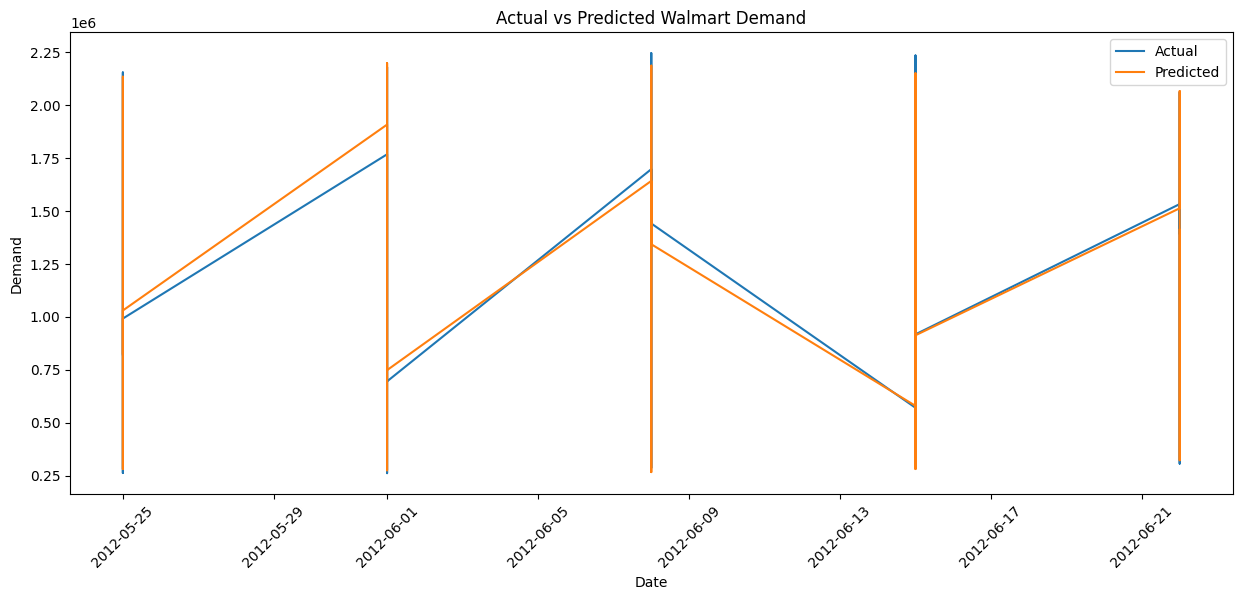

In [ ]:
plot_data = comparison.head(200)

plt.figure(figsize=(15, 6))

plt.plot(
    plot_data["date"],
    plot_data["sales"],
    label="Actual"
)

plt.plot(
    plot_data["date"],
    plot_data["predicted_sales"],
    label="Predicted"
)

plt.title("Actual vs Predicted Walmart Demand")

plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [ ]:
# ============================================
# 14. FUTURE DEMAND PREDICTION
# ============================================

latest = (
    sales_long
    .sort_values("date")
    .groupby("id")
    .tail(1)
    .copy()
)

print("Number of products/stores:", len(latest))

display(
    latest[
        [
            "id",
            "date",
            "sales",
            "lag_1",
            "lag_7",
            "lag_14",
            "lag_28"
        ]
    ].head()
)

Number of products/stores: 45


,id,date,sales,lag_1,lag_7,lag_14,lag_28
4146,29,2012-10-26,534970.68,516909.24,540811.85,506705.36,520493.83
714,5,2012-10-26,319550.77,313358.15,350648.91,321205.12,351832.03
5719,40,2012-10-26,921264.52,918170.50,1088248.40,968502.38,857811.17
5576,39,2012-10-26,1569502.00,1577486.33,1609811.75,1582168.27,1580732.73
3431,24,2012-10-26,1307182.29,1255414.84,1477134.75,1394299.00,1285783.87


In [ ]:
history = sales_long[
    [
        "id",
        "date",
        "sales"
    ]
].copy()

history = history.sort_values(
    ["id", "date"]
)

In [ ]:
last_date = history["date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days,
    freq="D"
)

print("Forecast starts:", future_dates.min())
print("Forecast ends:", future_dates.max())

Forecast starts: 2012-10-27 00:00:00
Forecast ends: 2012-11-25 00:00:00


In [ ]:
future_predictions = []

unique_ids = history["id"].unique()

for current_id in unique_ids:

    id_history = history[
        history["id"] == current_id
    ].copy()

    id_history = id_history.sort_values("date")

    sales_values = list(
        id_history["sales"].values
    )

    for future_date in future_dates:

        # -------------------------------
        # Lag features
        # -------------------------------

        lag_1 = sales_values[-1]

        lag_7 = (
            sales_values[-7]
            if len(sales_values) >= 7
            else np.mean(sales_values)
        )

        lag_14 = (
            sales_values[-14]
            if len(sales_values) >= 14
            else np.mean(sales_values)
        )

        lag_28 = (
            sales_values[-28]
            if len(sales_values) >= 28
            else np.mean(sales_values)
        )

        # -------------------------------
        # Rolling features
        # -------------------------------

        rolling_mean_7 = np.mean(
            sales_values[-7:]
        )

        rolling_mean_14 = np.mean(
            sales_values[-14:]
        )

        rolling_mean_28 = np.mean(
            sales_values[-28:]
        )

        rolling_std_7 = np.std(
            sales_values[-7:]
        )

        rolling_std_28 = np.std(
            sales_values[-28:]
        )

        # -------------------------------
        # Date features
        # -------------------------------

        year = future_date.year
        month = future_date.month
        day = future_date.day
        day_of_week = future_date.dayofweek

        week_of_year = (
            future_date.isocalendar().week
        )

        quarter = (
            (future_date.month - 1) // 3 + 1
        )

        is_weekend = int(
            day_of_week >= 5
        )

        # -------------------------------
        # Seasonal features
        # -------------------------------

        month_sin = np.sin(
            2 * np.pi * month / 12
        )

        month_cos = np.cos(
            2 * np.pi * month / 12
        )

        dow_sin = np.sin(
            2 * np.pi * day_of_week / 7
        )

        dow_cos = np.cos(
            2 * np.pi * day_of_week / 7
        )

        # -------------------------------
        # Future event feature
        # -------------------------------

        has_event = 0

        # -------------------------------
        # Create feature row
        # -------------------------------

        feature_row = pd.DataFrame([{

            "year": year,
            "month": month,
            "day": day,
            "day_of_week": day_of_week,
            "week_of_year": int(week_of_year),
            "quarter": quarter,
            "is_weekend": is_weekend,

            "lag_1": lag_1,
            "lag_7": lag_7,
            "lag_14": lag_14,
            "lag_28": lag_28,

            "rolling_mean_7": rolling_mean_7,
            "rolling_mean_14": rolling_mean_14,
            "rolling_mean_28": rolling_mean_28,

            "rolling_std_7": rolling_std_7,
            "rolling_std_28": rolling_std_28,

            "month_sin": month_sin,
            "month_cos": month_cos,

            "dow_sin": dow_sin,
            "dow_cos": dow_cos,

            "has_event": has_event
        }])

        # -------------------------------
        # Predict
        # -------------------------------

        prediction = best_model.predict(
            feature_row[features]
        )[0]

        # Demand cannot be negative

        prediction = max(
            0,
            prediction
        )

        # Store prediction

        future_predictions.append({

            "id": current_id,
            "date": future_date,
            "predicted_demand": prediction

        })

        # Add prediction to history
        # for next recursive prediction

        sales_values.append(
            prediction
        )

In [ ]:
future_forecast = pd.DataFrame(
    future_predictions
)

print(
    "Future forecast shape:",
    future_forecast.shape
)

display(
    future_forecast.head(20)
)

Future forecast shape: (1350, 3)


,id,date,predicted_demand
0,1,2012-10-27,1.430892e+06
1,1,2012-10-28,1.423798e+06
2,1,2012-10-29,1.422670e+06
3,1,2012-10-30,1.417669e+06
4,1,2012-10-31,1.403189e+06
5,1,2012-11-01,1.506215e+06
6,1,2012-11-02,1.574109e+06
7,1,2012-11-03,1.569557e+06
8,1,2012-11-04,1.570598e+06
9,1,2012-11-05,1.584568e+06


In [ ]:
# ==========================================
# FUTURE FORECAST SUMMARY
# ==========================================

forecast_summary = (
    future_forecast
    .groupby("date")["predicted_demand"]
    .sum()
    .reset_index()
)

forecast_summary.columns = [
    "date",
    "total_predicted_demand"
]

display(forecast_summary)

,date,total_predicted_demand
0,2012-10-27,4.520458e+07
1,2012-10-28,4.524152e+07
2,2012-10-29,4.538341e+07
3,2012-10-30,4.549287e+07
4,2012-10-31,4.542596e+07
5,2012-11-01,4.719404e+07
6,2012-11-02,4.807649e+07
7,2012-11-03,4.853083e+07
8,2012-11-04,4.886069e+07
9,2012-11-05,4.912716e+07


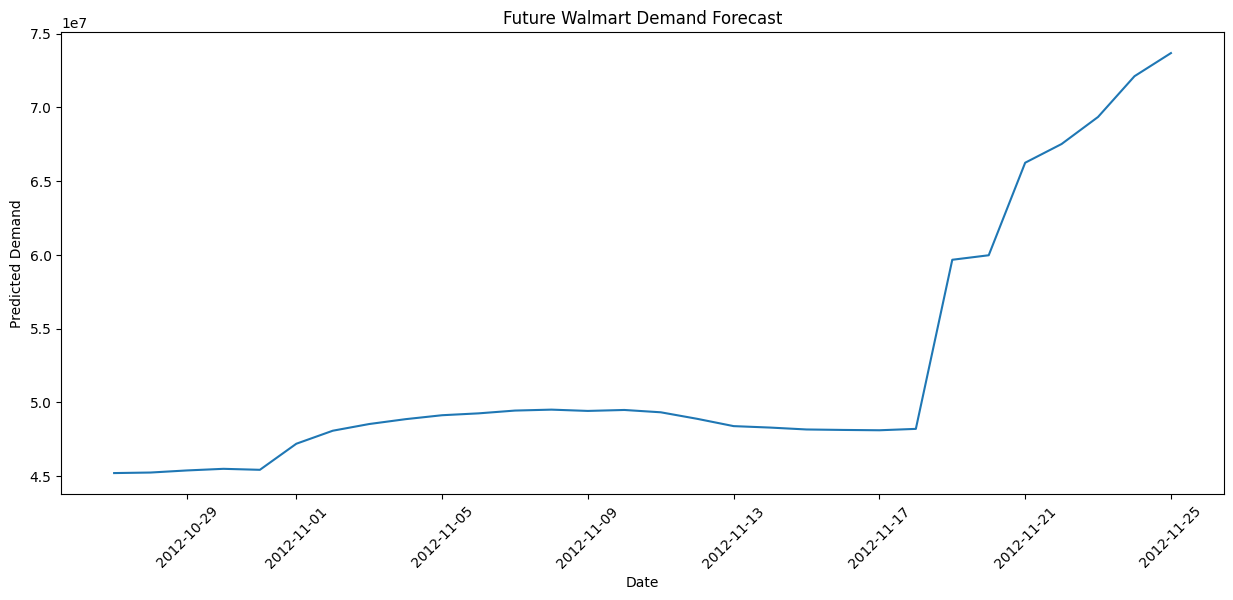

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    forecast_summary["date"],
    forecast_summary["total_predicted_demand"]
)

plt.title(
    "Future Walmart Demand Forecast"
)

plt.xlabel("Date")
plt.ylabel("Predicted Demand")

plt.xticks(rotation=45)

plt.show()

In [ ]:
future_forecast.to_csv(
    "walmart_future_demand_predictions.csv",
    index=False
)

results_df.to_csv(
    "walmart_model_results.csv",
    index=False
)

print("Forecast saved successfully.")

Forecast saved successfully.


# ***Rossmann Analytics***

* Load Dataset

* Data Cleaning & Preprocessing

* Merge Train and Store Datasets

* Exploratory Data Analysis (EDA)

* Promotion vs Non-Promotion Sales

* Promotion Lift % Analysis

* Store Performance Analysis

* Customer Behavior Analysis

* Seasonal Sales Analysis

* Day-of-Week Effects

* Holiday Impact Analysis

* Competition Analysis

* Visualization & Business Insights





In [ ]:
# ============================================================
# STEP 1: LOAD DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Rossmann datasets
train = pd.read_csv("./data/rossmann/train.csv")
store = pd.read_csv("./data/rossmann/store.csv")

# Display first 5 rows
print("Train Dataset:")
display(train.head())

print("\nStore Dataset:")
display(store.head())

# Check shape
print("\nTrain Shape:", train.shape)
print("Store Shape:", store.shape)

Train Dataset:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1



Store Dataset:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN



Train Shape: (1017209, 9)
Store Shape: (1115, 10)


In [ ]:
# ============================================================
# STEP 2: DATA CLEANING & PREPROCESSING
# ============================================================

# Check missing values
print("Missing values in Train:")
print(train.isnull().sum())

print("\nMissing values in Store:")
print(store.isnull().sum())

# Convert Date column to datetime
train["Date"] = pd.to_datetime(train["Date"])

# Check duplicate records
print("\nDuplicate rows in Train:", train.duplicated().sum())
print("Duplicate rows in Store:", store.duplicated().sum())

# Remove duplicates
train = train.drop_duplicates()
store = store.drop_duplicates()

# Check data types
print("\nTrain Data Types:")
print(train.dtypes)

# Display basic statistics
print("\nTrain Statistics:")
display(train.describe())

Missing values in Train:
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Missing values in Store:
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

Duplicate rows in Train: 0
Duplicate rows in Store: 0

Train Data Types:
Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object

Train Statistics:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01


In [ ]:
# ============================================================
# STEP 3: MERGE TRAIN AND STORE DATASETS
# ============================================================

# Merge both datasets using Store column
df = pd.merge(
    train,
    store,
    on="Store",
    how="left"
)

# Display merged dataset
display(df.head())

# Check shape
print("Merged Dataset Shape:", df.shape)

# Check columns
print("\nColumns:")
print(df.columns.tolist())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


Merged Dataset Shape: (1017209, 18)

Columns:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [ ]:
# ============================================================
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Basic information
print("Dataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Number of unique stores
print("\nNumber of Stores:", df["Store"].nunique())

# Total sales
print("Total Sales:", df["Sales"].sum())

# Total customers
print("Total Customers:", df["Customers"].sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDista

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870



Missing Values:
Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

Number of Stores: 1115
Total Sales: 5873180623
Total Customers: 644041755


Average Sales:
Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64


,Promo,sum,mean,count
0,No Promotion,2771974337,4406.050805,629129
1,Promotion,3101206286,7991.152046,388080


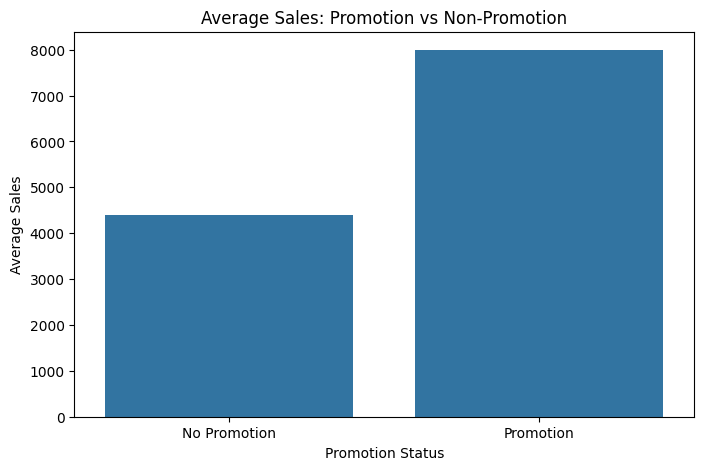

In [ ]:
# ============================================================
# STEP 5: PROMOTION VS NON-PROMOTION SALES
# ============================================================

# Calculate average sales for promotion and non-promotion days
promotion_sales = df.groupby("Promo")["Sales"].mean()

print("Average Sales:")
print(promotion_sales)

# Convert Promo values to readable labels
promo_labels = {
    0: "No Promotion",
    1: "Promotion"
}

promotion_comparison = df.groupby("Promo")["Sales"].agg(
    ["sum", "mean", "count"]
).reset_index()

promotion_comparison["Promo"] = promotion_comparison["Promo"].map(promo_labels)

display(promotion_comparison)

# Visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    data=promotion_comparison,
    x="Promo",
    y="mean"
)

plt.title("Average Sales: Promotion vs Non-Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Average Sales")
plt.show()

In [ ]:
# ============================================================
# STEP 6: PROMOTION LIFT %
# ============================================================

# Average sales without promotion
non_promo_sales = df[df["Promo"] == 0]["Sales"].mean()

# Average sales with promotion
promo_sales = df[df["Promo"] == 1]["Sales"].mean()

# Calculate promotion lift
promotion_lift = (
    (promo_sales - non_promo_sales)
    / non_promo_sales
) * 100

print("Average Sales without Promotion:", non_promo_sales)
print("Average Sales with Promotion:", promo_sales)
print("Promotion Lift: {:.2f}%".format(promotion_lift))

Average Sales without Promotion: 4406.050805160786
Average Sales with Promotion: 7991.152045969903
Promotion Lift: 81.37%


Top 10 Stores by Total Sales:


,Store,Total_Sales,Average_Sales,Total_Customers,Average_Customers
261,262,19516842,20718.515924,3204694,3402.010616
816,817,17057867,18108.139066,2454370,2605.488323
561,562,16927322,17969.556263,2924960,3105.053079
1113,1114,16202585,17200.196391,2509542,2664.057325
250,251,14896870,15814.087049,1908934,2026.469214
512,513,14252406,15129.942675,1643527,1744.720807
787,788,14082141,14949.194268,1346835,1429.761146
732,733,14067158,14933.288747,3206058,3403.458599
382,383,13489879,14320.466030,1720249,1826.166667
755,756,12911782,13706.774947,1827980,1940.530786


Bottom 10 Stores by Total Sales:


,Store,Total_Sales,Average_Sales,Total_Customers,Average_Customers
971,972,2402627,2550.559448,272238,289.000000
185,186,2353548,3104.944591,237019,312.689974
253,254,2341661,2485.839703,201507,213.914013
878,879,2340576,3087.831135,216037,285.009235
840,841,2318635,2461.395966,321495,341.289809
262,263,2306075,3042.315303,221342,292.007916
207,208,2302052,2443.791932,324162,344.121019
197,198,2268273,2407.933121,264690,280.987261
542,543,2179287,2313.468153,187583,199.132696
306,307,2114322,2244.503185,240704,255.524416


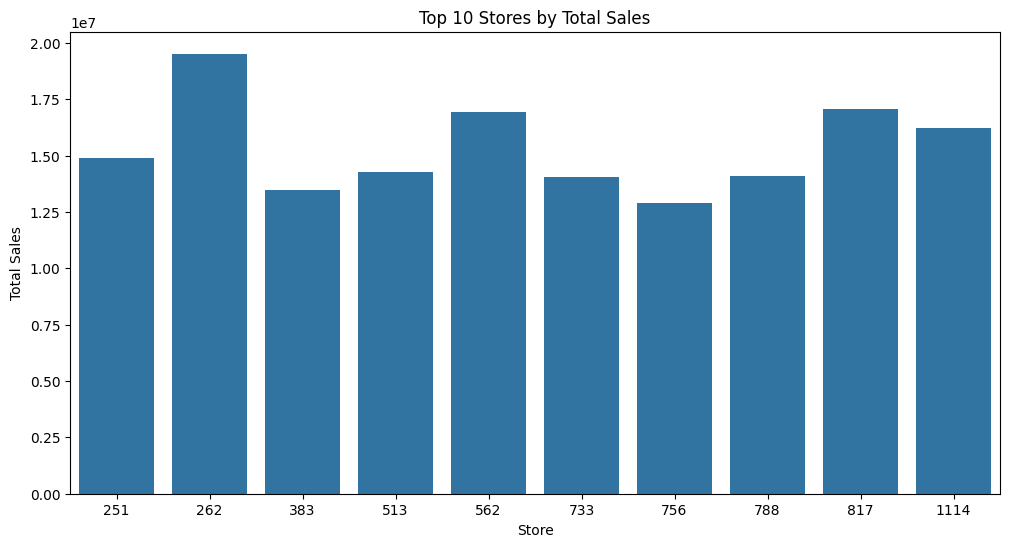

In [ ]:
# ============================================================
# STEP 7: STORE PERFORMANCE ANALYSIS
# ============================================================

# Calculate store-level performance
store_performance = df.groupby("Store").agg(
    Total_Sales=("Sales", "sum"),
    Average_Sales=("Sales", "mean"),
    Total_Customers=("Customers", "sum"),
    Average_Customers=("Customers", "mean")
).reset_index()

# Sort by total sales
store_performance = store_performance.sort_values(
    by="Total_Sales",
    ascending=False
)

# Top 10 stores
print("Top 10 Stores by Total Sales:")
display(store_performance.head(10))

# Bottom 10 stores
print("Bottom 10 Stores by Total Sales:")
display(store_performance.tail(10))

# Visualization
plt.figure(figsize=(12, 6))

sns.barplot(
    data=store_performance.head(10),
    x="Store",
    y="Total_Sales"
)

plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

Average Customers per Day: 633.1459464082602
Average Sales per Customer: 7.880231367686532

Customer-Sales Correlation:


,Customers,Sales
Customers,1.000000,0.894711
Sales,0.894711,1.000000


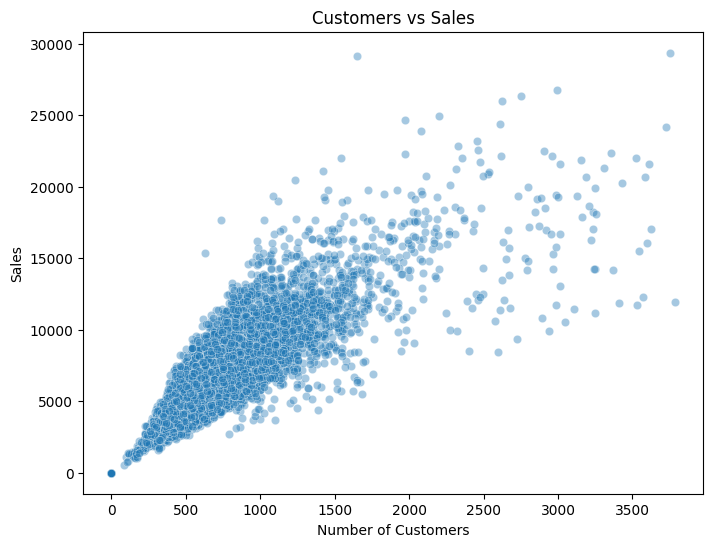

In [ ]:
# ============================================================
# STEP 8: CUSTOMER BEHAVIOR ANALYSIS
# ============================================================

# Calculate sales per customer
df["Sales_Per_Customer"] = np.where(
    df["Customers"] > 0,
    df["Sales"] / df["Customers"],
    0
)

# Overall customer statistics
print("Average Customers per Day:",
      df["Customers"].mean())

print("Average Sales per Customer:",
      df["Sales_Per_Customer"].mean())

# Correlation between customers and sales
customer_sales_corr = df[
    ["Customers", "Sales"]
].corr()

print("\nCustomer-Sales Correlation:")
display(customer_sales_corr)

# Visualization
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df.sample(min(10000, len(df))),
    x="Customers",
    y="Sales",
    alpha=0.4
)

plt.title("Customers vs Sales")
plt.xlabel("Number of Customers")
plt.ylabel("Sales")
plt.show()

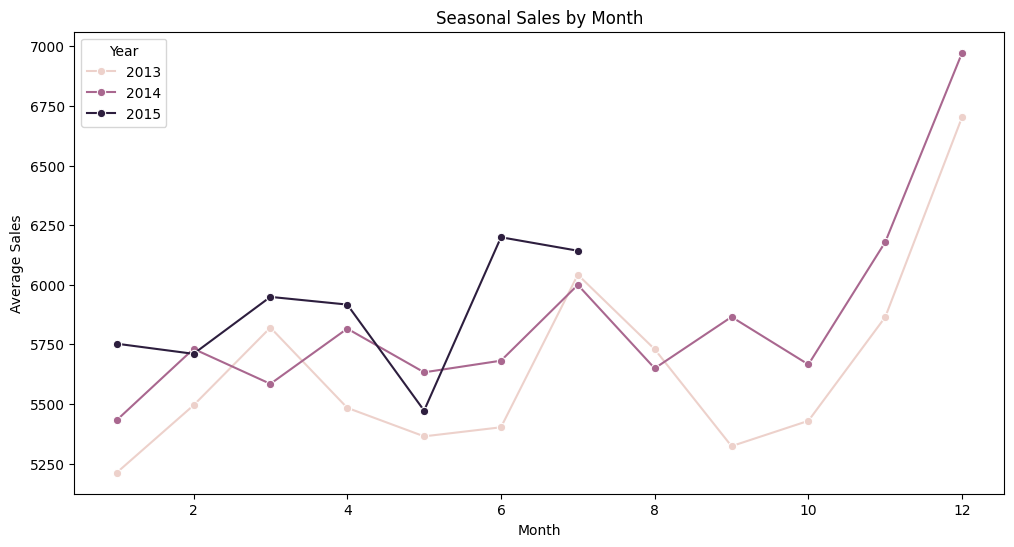

Average Sales by Month:


,Sales
Month_Name,
December,6826.611377
July,6064.915711
November,6008.111821
March,5784.578871
June,5760.964375
April,5738.866916
August,5693.016554
February,5645.253150
September,5570.246033


In [ ]:
# ============================================================
# STEP 9: SEASONAL SALES ANALYSIS
# ============================================================

# Create date-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

# Monthly sales
monthly_sales = df.groupby(
    ["Year", "Month"]
)["Sales"].mean().reset_index()

# Visualization
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Seasonal Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

# Month-wise sales
month_sales = df.groupby(
    "Month_Name"
)["Sales"].mean().sort_values(ascending=False)

print("Average Sales by Month:")
display(month_sales)

Average Sales by Day:


,Sales
Day_Name,
Monday,7809.044510
Tuesday,7005.244467
Wednesday,6555.884138
Thursday,6247.575913
Friday,6723.274305
Saturday,5847.562599
Sunday,204.183189


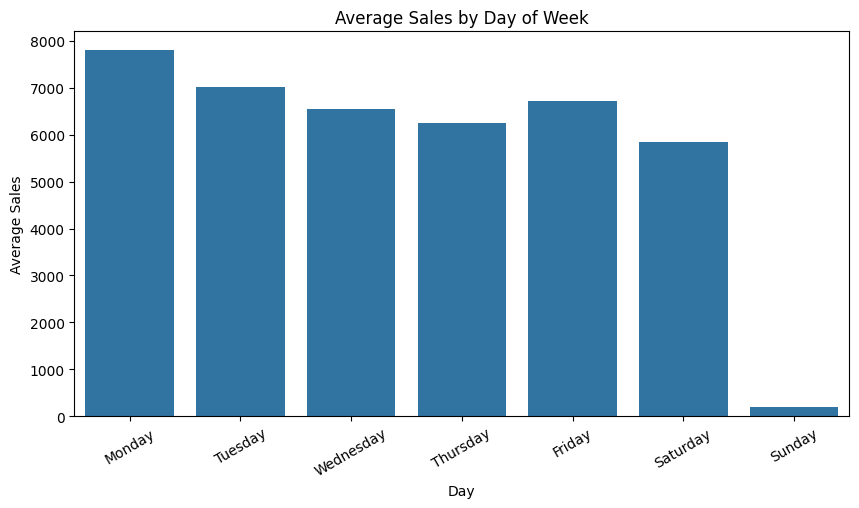

In [ ]:
# ============================================================
# STEP 10: DAY-OF-WEEK EFFECTS
# ============================================================

# Create day name
df["Day_Name"] = df["Date"].dt.day_name()

# Average sales by day
day_sales = df.groupby(
    "Day_Name"
)["Sales"].mean().reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

print("Average Sales by Day:")
display(day_sales)

# Visualization
plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_sales.index,
    y=day_sales.values
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")
plt.xticks(rotation=30)
plt.show()

Sales by State Holiday:


,StateHoliday,mean,sum,count
0,0,5733.530624,751505326,131072
1,0,5980.279717,5113659442,855087
2,a,290.735686,5890305,20260
3,b,214.311510,1433744,6690
4,c,168.733171,691806,4100



Average Sales: School Holiday vs Normal Day


,Sales
SchoolHoliday,
0,5620.979034
1,6476.522207


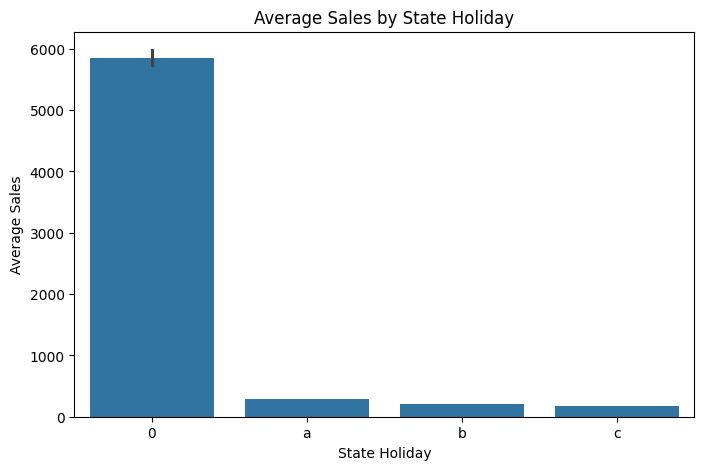

In [ ]:
# ============================================================
# STEP 11: HOLIDAY IMPACT ANALYSIS
# ============================================================

# StateHoliday:
# 0 = No holiday
# Other values represent holidays

holiday_sales = df.groupby(
    "StateHoliday"
)["Sales"].agg(
    ["mean", "sum", "count"]
).reset_index()

print("Sales by State Holiday:")
display(holiday_sales)

# School holiday impact
school_holiday_sales = df.groupby(
    "SchoolHoliday"
)["Sales"].mean()

print("\nAverage Sales: School Holiday vs Normal Day")
display(school_holiday_sales)

# Visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    data=holiday_sales,
    x="StateHoliday",
    y="mean"
)

plt.title("Average Sales by State Holiday")
plt.xlabel("State Holiday")
plt.ylabel("Average Sales")
plt.show()

Competition Distance Statistics:


,CompetitionDistance
count,1.014567e+06
mean,5.430086e+03
std,7.715324e+03
min,2.000000e+01
25%,7.100000e+02
50%,2.330000e+03
75%,6.890000e+03
max,7.586000e+04


Average Sales by Competition Level:


,Competition_Level,Sales
0,Near Competition,6063.365791
1,Medium Competition,5675.492669
2,Far Competition,5630.984132


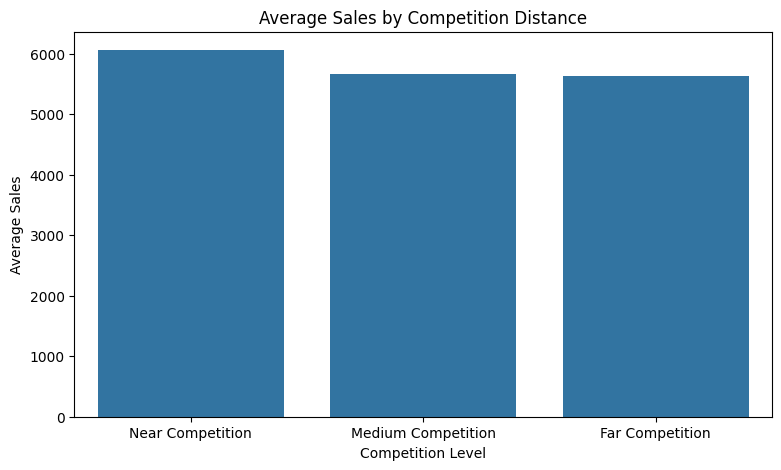

Correlation between Competition Distance and Sales: -0.01922920050311119


In [ ]:
# ============================================================
# STEP 12: COMPETITION ANALYSIS
# ============================================================

# Check competition distance
print("Competition Distance Statistics:")
display(df["CompetitionDistance"].describe())

# Create competition categories
df["Competition_Level"] = pd.cut(
    df["CompetitionDistance"],
    bins=[-1, 1000, 5000, np.inf],
    labels=[
        "Near Competition",
        "Medium Competition",
        "Far Competition"
    ]
)

# Compare sales by competition level
competition_sales = df.groupby(
    "Competition_Level",
    observed=False
)["Sales"].mean().reset_index()

print("Average Sales by Competition Level:")
display(competition_sales)

# Visualization
plt.figure(figsize=(9, 5))

sns.barplot(
    data=competition_sales,
    x="Competition_Level",
    y="Sales"
)

plt.title("Average Sales by Competition Distance")
plt.xlabel("Competition Level")
plt.ylabel("Average Sales")
plt.show()

# Correlation
print(
    "Correlation between Competition Distance and Sales:",
    df["CompetitionDistance"].corr(df["Sales"])
)

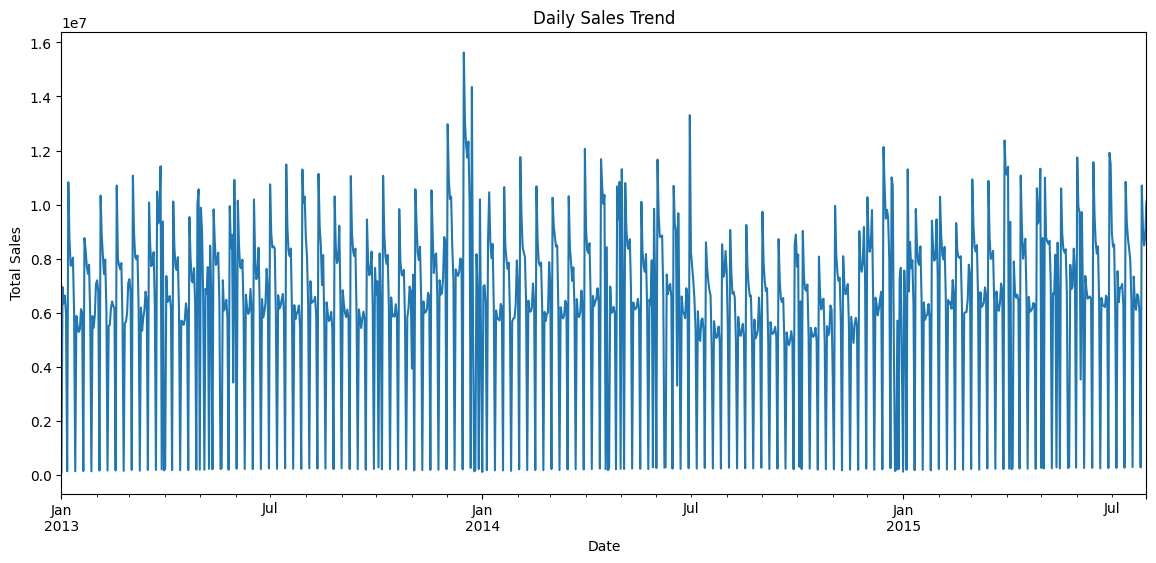

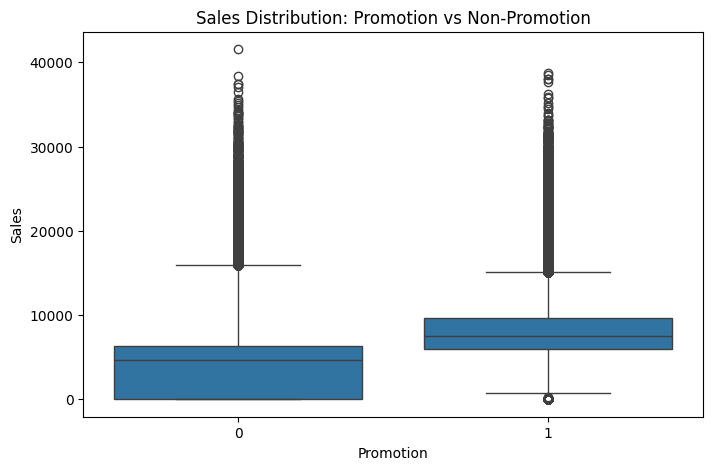

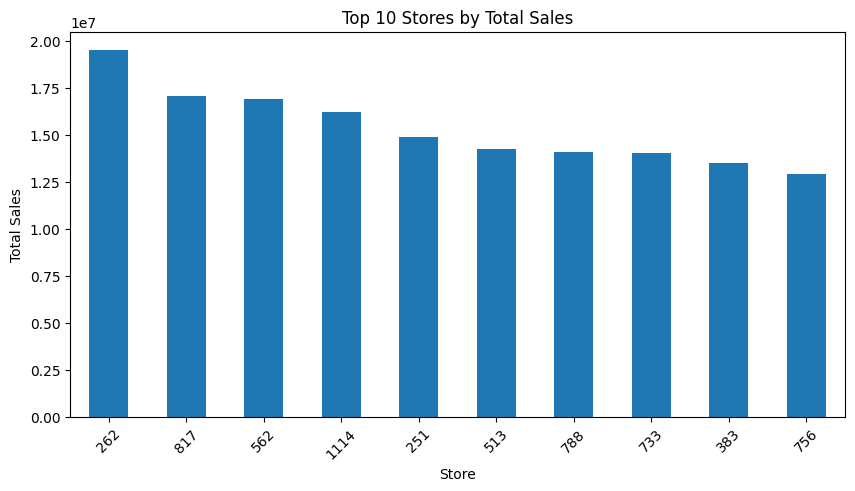

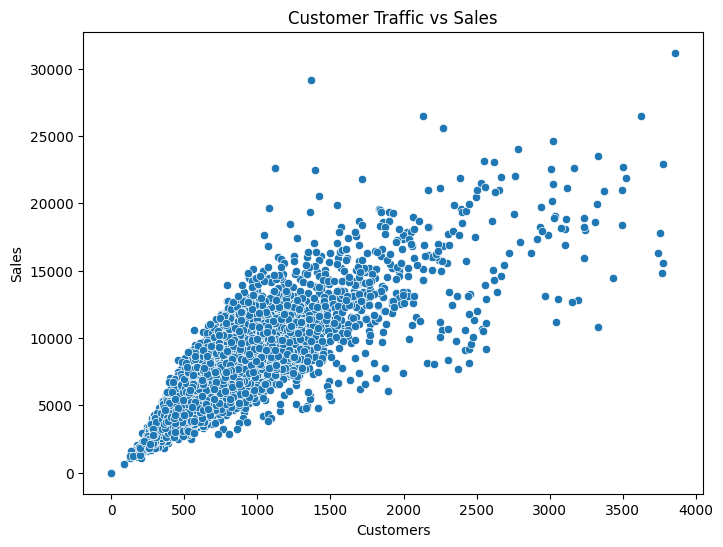

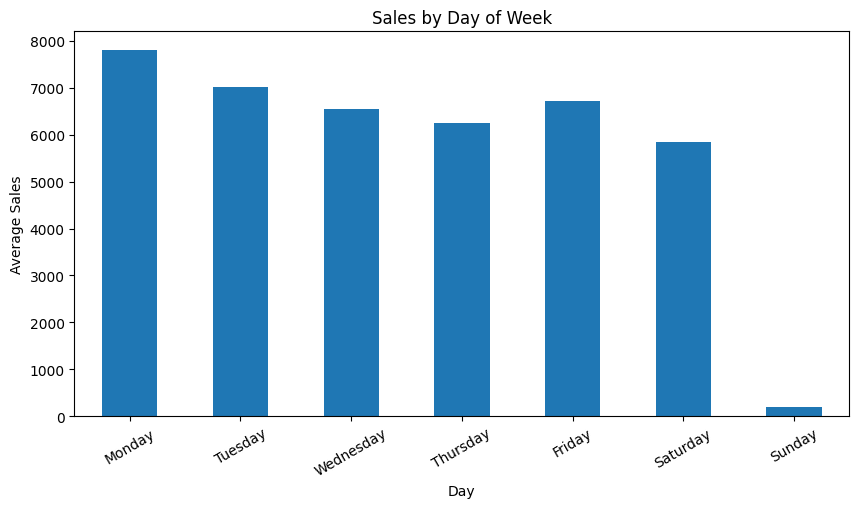

In [ ]:
# ============================================================
# STEP 13: VISUALIZATION & BUSINESS INSIGHTS
# ============================================================

# -------------------------------
# 1. Sales Trend
# -------------------------------

daily_sales = df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(14, 6))

daily_sales.plot()

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()


# -------------------------------
# 2. Promotion Comparison
# -------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Promo",
    y="Sales"
)

plt.title("Sales Distribution: Promotion vs Non-Promotion")
plt.xlabel("Promotion")
plt.ylabel("Sales")
plt.show()


# -------------------------------
# 3. Top 10 Stores
# -------------------------------

top_stores = (
    df.groupby("Store")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

top_stores.plot(kind="bar")

plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


# -------------------------------
# 4. Customers vs Sales
# -------------------------------

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df.sample(min(10000, len(df))),
    x="Customers",
    y="Sales"
)

plt.title("Customer Traffic vs Sales")
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.show()


# -------------------------------
# 5. Day-of-Week Performance
# -------------------------------

plt.figure(figsize=(10, 5))

day_sales.plot(kind="bar")

plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")
plt.xticks(rotation=30)
plt.show()

In [ ]:
# ============================================================
# FINAL BUSINESS INSIGHTS
# ============================================================

print("========== ROSSMANN BUSINESS INSIGHTS ==========")

print(
    f"1. Promotion Lift: {promotion_lift:.2f}%"
)

print(
    f"2. Top Performing Store: "
    f"{store_performance.iloc[0]['Store']}"
)

print(
    f"3. Top Store Total Sales: "
    f"{store_performance.iloc[0]['Total_Sales']:.2f}"
)

print(
    f"4. Average Sales per Customer: "
    f"{df['Sales_Per_Customer'].mean():.2f}"
)

print(
    f"5. Best Sales Day: "
    f"{day_sales.idxmax()} "
    f"({day_sales.max():.2f})"
)

print(
    f"6. Lowest Sales Day: "
    f"{day_sales.idxmin()} "
    f"({day_sales.min():.2f})"
)

print(
    f"7. Customer-Sales Correlation: "
    f"{df['Customers'].corr(df['Sales']):.2f}"
)

print(
    f"8. Competition Distance-Sales Correlation: "
    f"{df['CompetitionDistance'].corr(df['Sales']):.2f}"
)

========== ROSSMANN BUSINESS INSIGHTS ==========
1. Promotion Lift: 81.37%
2. Top Performing Store: 262.0
3. Top Store Total Sales: 19516842.00
4. Average Sales per Customer: 7.88
5. Best Sales Day: Monday (7809.04)
6. Lowest Sales Day: Sunday (204.18)
7. Customer-Sales Correlation: 0.89
8. Competition Distance-Sales Correlation: -0.02


# ***Supply-Chain Inventory Optimization***

1. Dataset Download & Extraction

2. Data Loading

3. Data Understanding & Profiling

4. Data Cleaning

5. Data Integration

6. Daily Product Demand Calculation

7. Demand Forecasting

8. Demand Variability Analysis

9. Lead-Time Analysis

10. Safety Stock Calculation

11. Reorder Point Calculation

12. EOQ Calculation

13. Recommended Order Quantity

14. Stockout Risk Analysis

15. Overstock Risk Analysis

16. Inventory Health Classification

17. Product-Level Inventory Analysis

18. Reorder Recommendation Generation

19. CSV Output Generation

20. Business Summary & Insights

In [ ]:
# ============================================================
# STEP 1 - LOAD INSTACART DATASET
# ============================================================

import os
import numpy as np
import pandas as pd

DATA_PATH = "./data/instacart"

orders = pd.read_csv(
    f"{DATA_PATH}/orders.csv"
)

products = pd.read_csv(
    f"{DATA_PATH}/products.csv"
)

aisles = pd.read_csv(
    f"{DATA_PATH}/aisles.csv"
)

departments = pd.read_csv(
    f"{DATA_PATH}/departments.csv"
)

print("Orders:", orders.shape)
print("Products:", products.shape)
print("Aisles:", aisles.shape)
print("Departments:", departments.shape)

orders.head()

Orders: (3421083, 7)
Products: (49688, 4)
Aisles: (134, 2)
Departments: (21, 2)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [ ]:
# ============================================================
# STEP 2 - LOAD PRIOR ORDER PRODUCTS
# ============================================================

PRIOR_FILE = f"{DATA_PATH}/order_products__prior.csv"

prior = pd.read_csv(
    PRIOR_FILE,
    usecols=[
        "order_id",
        "product_id",
        "add_to_cart_order",
        "reordered"
    ]
)

print("Prior order-product records:", prior.shape)

prior.head()

Prior order-product records: (32434489, 4)


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [ ]:
# ============================================================
# MEMORY-SAFE VERSION
# ============================================================

chunks = []

for chunk in pd.read_csv(
    PRIOR_FILE,
    usecols=[
        "order_id",
        "product_id",
        "add_to_cart_order",
        "reordered"
    ],
    chunksize=500000
):
    chunks.append(chunk)

prior = pd.concat(chunks, ignore_index=True)

print("Loaded:", prior.shape)

Loaded: (32434489, 4)


In [ ]:
# ============================================================
# STEP 3 - CREATE APPROXIMATE ORDER TIMELINE
# ============================================================

orders = orders.sort_values(
    ["user_id", "order_number"]
).reset_index(drop=True)

# Missing value for first order = 0
orders["days_since_prior_order"] = (
    orders["days_since_prior_order"]
    .fillna(0)
)

# Cumulative days for each customer
orders["day_index"] = (
    orders
    .groupby("user_id")["days_since_prior_order"]
    .cumsum()
)

orders[
    [
        "order_id",
        "user_id",
        "order_number",
        "days_since_prior_order",
        "day_index"
    ]
].head(10)

,order_id,user_id,order_number,days_since_prior_order,day_index
0,2539329,1,1,0.0,0.0
1,2398795,1,2,15.0,15.0
2,473747,1,3,21.0,36.0
3,2254736,1,4,29.0,65.0
4,431534,1,5,28.0,93.0
5,3367565,1,6,19.0,112.0
6,550135,1,7,20.0,132.0
7,3108588,1,8,14.0,146.0
8,2295261,1,9,0.0,146.0
9,2550362,1,10,30.0,176.0


In [ ]:
# ============================================================
# STEP 4 - MERGE ORDERS + PRIOR PRODUCTS
# ============================================================

order_products = prior.merge(
    orders[
        [
            "order_id",
            "user_id",
            "order_number",
            "day_index"
        ]
    ],
    on="order_id",
    how="inner"
)

print("Merged dataset:", order_products.shape)

order_products.head()

Merged dataset: (32434489, 7)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,day_index
0,2,33120,1,1,202279,3,28.0
1,2,28985,2,1,202279,3,28.0
2,2,9327,3,0,202279,3,28.0
3,2,45918,4,1,202279,3,28.0
4,2,30035,5,0,202279,3,28.0


In [ ]:
# ============================================================
# STEP 5 - DAILY PRODUCT DEMAND
# ============================================================

daily_demand = (
    order_products
    .groupby(
        ["product_id", "day_index"]
    )
    .size()
    .reset_index(name="daily_demand")
)

print("Daily demand records:", daily_demand.shape)

daily_demand.head()

Daily demand records: (5073107, 3)


,product_id,day_index,daily_demand
0,1,0.0,103
1,1,1.0,1
2,1,2.0,4
3,1,3.0,5
4,1,4.0,2


In [ ]:
# ============================================================
# STEP 6 - DEMAND FORECAST
# ============================================================

MAX_DAY = daily_demand["day_index"].max()

RECENT_DAYS = 28

recent_demand = daily_demand[
    daily_demand["day_index"] >= MAX_DAY - RECENT_DAYS + 1
]

forecast = (
    recent_demand
    .groupby("product_id")["daily_demand"]
    .agg(
        forecast_demand="mean",
        demand_std="std",
        total_recent_demand="sum",
        active_days="count"
    )
    .reset_index()
)

# Products with only one observation
forecast["demand_std"] = forecast["demand_std"].fillna(0)

# Avoid zero forecast
forecast["forecast_demand"] = (
    forecast["forecast_demand"].clip(lower=0.01)
)

forecast.head()

,product_id,forecast_demand,demand_std,total_recent_demand,active_days
0,1,1.6,0.910259,24,15
1,2,1.0,0.000000,1,1
2,3,1.0,0.000000,1,1
3,4,1.0,0.000000,3,3
4,8,1.0,0.000000,3,3


In [ ]:
# ============================================================
# STEP 7 - DEMAND VARIABILITY
# ============================================================

forecast["demand_variability"] = forecast["demand_std"]

forecast["coefficient_of_variation"] = np.where(
    forecast["forecast_demand"] > 0,
    forecast["demand_std"] /
    forecast["forecast_demand"],
    0
)

forecast[
    [
        "product_id",
        "forecast_demand",
        "demand_std",
        "coefficient_of_variation"
    ]
].head()

,product_id,forecast_demand,demand_std,coefficient_of_variation
0,1,1.6,0.910259,0.568912
1,2,1.0,0.000000,0.000000
2,3,1.0,0.000000,0.000000
3,4,1.0,0.000000,0.000000
4,8,1.0,0.000000,0.000000


In [ ]:
# ============================================================
# STEP 8 - INVENTORY BUSINESS ASSUMPTIONS
# ============================================================

# Service level
SERVICE_LEVEL = 0.95

# Z-score for 95% service level
Z_SCORE = 1.645

# Assumed supplier lead time
LEAD_TIME_DAYS = 7

# Inventory review period
REVIEW_PERIOD_DAYS = 7

# Forecast horizon
FORECAST_HORIZON_DAYS = 7

# Assumed ordering cost per order
ORDERING_COST = 50

# Assumed holding cost per unit per year
HOLDING_COST = 2

# Assume 365 inventory days
DAYS_PER_YEAR = 365

print("Service Level:", SERVICE_LEVEL)
print("Lead Time:", LEAD_TIME_DAYS, "days")
print("Ordering Cost:", ORDERING_COST)
print("Holding Cost:", HOLDING_COST)

Service Level: 0.95
Lead Time: 7 days
Ordering Cost: 50
Holding Cost: 2


In [ ]:
# ============================================================
# STEP 9 - SAFETY STOCK
# ============================================================

forecast["safety_stock"] = (
    Z_SCORE
    * forecast["demand_std"]
    * np.sqrt(LEAD_TIME_DAYS)
)

forecast["safety_stock"] = (
    forecast["safety_stock"].fillna(0)
)

forecast.head()

,product_id,forecast_demand,demand_std,total_recent_demand,active_days,demand_variability,coefficient_of_variation,safety_stock
0,1,1.6,0.910259,24,15,0.910259,0.568912,3.961685
1,2,1.0,0.000000,1,1,0.000000,0.000000,0.000000
2,3,1.0,0.000000,1,1,0.000000,0.000000,0.000000
3,4,1.0,0.000000,3,3,0.000000,0.000000,0.000000
4,8,1.0,0.000000,3,3,0.000000,0.000000,0.000000


In [ ]:
# ============================================================
# STEP 10 - REORDER POINT
# ============================================================

forecast["reorder_point"] = (
    forecast["forecast_demand"]
    * LEAD_TIME_DAYS
    + forecast["safety_stock"]
)

forecast["reorder_point"] = (
    np.ceil(forecast["reorder_point"])
)

forecast.head()

,product_id,forecast_demand,demand_std,total_recent_demand,active_days,demand_variability,coefficient_of_variation,safety_stock,reorder_point
0,1,1.6,0.910259,24,15,0.910259,0.568912,3.961685,16.0
1,2,1.0,0.000000,1,1,0.000000,0.000000,0.000000,7.0
2,3,1.0,0.000000,1,1,0.000000,0.000000,0.000000,7.0
3,4,1.0,0.000000,3,3,0.000000,0.000000,0.000000,7.0
4,8,1.0,0.000000,3,3,0.000000,0.000000,0.000000,7.0


In [ ]:
# ============================================================
# STEP 11 - ECONOMIC ORDER QUANTITY
# ============================================================

forecast["annual_demand"] = (
    forecast["forecast_demand"]
    * DAYS_PER_YEAR
)

forecast["eoq"] = np.sqrt(
    (
        2
        * forecast["annual_demand"]
        * ORDERING_COST
    )
    / HOLDING_COST
)

forecast["eoq"] = np.ceil(
    forecast["eoq"]
)

forecast.head()

,product_id,forecast_demand,demand_std,total_recent_demand,active_days,demand_variability,coefficient_of_variation,safety_stock,reorder_point,annual_demand,eoq
0,1,1.6,0.910259,24,15,0.910259,0.568912,3.961685,16.0,584.0,171.0
1,2,1.0,0.000000,1,1,0.000000,0.000000,0.000000,7.0,365.0,136.0
2,3,1.0,0.000000,1,1,0.000000,0.000000,0.000000,7.0,365.0,136.0
3,4,1.0,0.000000,3,3,0.000000,0.000000,0.000000,7.0,365.0,136.0
4,8,1.0,0.000000,3,3,0.000000,0.000000,0.000000,7.0,365.0,136.0


In [ ]:
# ============================================================
# STEP 12 - RECOMMENDED ORDER QUANTITY
# ============================================================

ASSUMED_CURRENT_INVENTORY_DAYS = 5

forecast["estimated_current_inventory"] = (
    forecast["forecast_demand"]
    * ASSUMED_CURRENT_INVENTORY_DAYS
)

forecast["target_inventory"] = (
    forecast["reorder_point"]
    + forecast["eoq"]
)

forecast["recommended_order_quantity"] = (
    forecast["target_inventory"]
    - forecast["estimated_current_inventory"]
)

forecast["recommended_order_quantity"] = (
    forecast["recommended_order_quantity"]
    .clip(lower=0)
)

forecast["recommended_order_quantity"] = (
    np.ceil(forecast["recommended_order_quantity"])
)

forecast.head()

,product_id,forecast_demand,demand_std,total_recent_demand,active_days,demand_variability,coefficient_of_variation,safety_stock,reorder_point,annual_demand,eoq,estimated_current_inventory,target_inventory,recommended_order_quantity
0,1,1.6,0.910259,24,15,0.910259,0.568912,3.961685,16.0,584.0,171.0,8.0,187.0,179.0
1,2,1.0,0.000000,1,1,0.000000,0.000000,0.000000,7.0,365.0,136.0,5.0,143.0,138.0
2,3,1.0,0.000000,1,1,0.000000,0.000000,0.000000,7.0,365.0,136.0,5.0,143.0,138.0
3,4,1.0,0.000000,3,3,0.000000,0.000000,0.000000,7.0,365.0,136.0,5.0,143.0,138.0
4,8,1.0,0.000000,3,3,0.000000,0.000000,0.000000,7.0,365.0,136.0,5.0,143.0,138.0


In [ ]:
# ============================================================
# STEP 13 - STOCKOUT RISK
# ============================================================

forecast["stockout_risk_ratio"] = np.where(
    forecast["reorder_point"] > 0,
    forecast["estimated_current_inventory"]
    / forecast["reorder_point"],
    999
)

def classify_stockout_risk(x):
    if x < 0.50:
        return "Very High"
    elif x < 0.80:
        return "High"
    elif x < 1.00:
        return "Medium"
    else:
        return "Low"

forecast["stockout_risk"] = (
    forecast["stockout_risk_ratio"]
    .apply(classify_stockout_risk)
)

forecast[
    [
        "product_id",
        "estimated_current_inventory",
        "reorder_point",
        "stockout_risk_ratio",
        "stockout_risk"
    ]
].head()

,product_id,estimated_current_inventory,reorder_point,stockout_risk_ratio,stockout_risk
0,1,8.0,16.0,0.500000,High
1,2,5.0,7.0,0.714286,High
2,3,5.0,7.0,0.714286,High
3,4,5.0,7.0,0.714286,High
4,8,5.0,7.0,0.714286,High


In [ ]:
# ============================================================
# STEP 14 - OVERSTOCK RISK
# ============================================================

forecast["overstock_ratio"] = np.where(
    forecast["target_inventory"] > 0,
    forecast["estimated_current_inventory"]
    / forecast["target_inventory"],
    0
)

def classify_overstock_risk(x):
    if x > 2.0:
        return "Very High"
    elif x > 1.5:
        return "High"
    elif x > 1.2:
        return "Medium"
    else:
        return "Low"

forecast["overstock_risk"] = (
    forecast["overstock_ratio"]
    .apply(classify_overstock_risk)
)

forecast[
    [
        "product_id",
        "estimated_current_inventory",
        "target_inventory",
        "overstock_ratio",
        "overstock_risk"
    ]
].head()

,product_id,estimated_current_inventory,target_inventory,overstock_ratio,overstock_risk
0,1,8.0,187.0,0.042781,Low
1,2,5.0,143.0,0.034965,Low
2,3,5.0,143.0,0.034965,Low
3,4,5.0,143.0,0.034965,Low
4,8,5.0,143.0,0.034965,Low


In [ ]:
# ============================================================
# STEP 15 - INVENTORY HEALTH
# ============================================================

def inventory_health(row):

    stockout = row["stockout_risk"]
    overstock = row["overstock_risk"]

    if stockout == "Very High":
        return "Critical - Stockout"

    elif stockout == "High":
        return "At Risk - Reorder"

    elif overstock == "Very High":
        return "Critical - Overstock"

    elif overstock == "High":
        return "Overstock"

    elif stockout == "Medium":
        return "Monitor"

    else:
        return "Healthy"


forecast["inventory_health"] = (
    forecast.apply(
        inventory_health,
        axis=1
    )
)

forecast["inventory_health"].value_counts()

,count
inventory_health,
At Risk - Reorder,24270
Critical - Stockout,815


In [ ]:
# ============================================================
# STEP 16 - ADD PRODUCT INFORMATION
# ============================================================

inventory_optimization = forecast.merge(
    products[
        [
            "product_id",
            "product_name",
            "aisle_id",
            "department_id"
        ]
    ],
    on="product_id",
    how="left"
)

inventory_optimization = inventory_optimization.merge(
    aisles,
    on="aisle_id",
    how="left"
)

inventory_optimization = inventory_optimization.merge(
    departments,
    on="department_id",
    how="left"
)

inventory_optimization.head()

,product_id,forecast_demand,demand_std,total_recent_demand,active_days,demand_variability,coefficient_of_variation,safety_stock,reorder_point,annual_demand,...,stockout_risk_ratio,stockout_risk,overstock_ratio,overstock_risk,inventory_health,product_name,aisle_id,department_id,aisle,department
0,1,1.6,0.910259,24,15,0.910259,0.568912,3.961685,16.0,584.0,...,0.500000,High,0.042781,Low,At Risk - Reorder,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,1.0,0.000000,1,1,0.000000,0.000000,0.000000,7.0,365.0,...,0.714286,High,0.034965,Low,At Risk - Reorder,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,1.0,0.000000,1,1,0.000000,0.000000,0.000000,7.0,365.0,...,0.714286,High,0.034965,Low,At Risk - Reorder,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,1.0,0.000000,3,3,0.000000,0.000000,0.000000,7.0,365.0,...,0.714286,High,0.034965,Low,At Risk - Reorder,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,8,1.0,0.000000,3,3,0.000000,0.000000,0.000000,7.0,365.0,...,0.714286,High,0.034965,Low,At Risk - Reorder,Cut Russet Potatoes Steam N' Mash,116,1,frozen produce,frozen


In [ ]:
# ============================================================
# STEP 17 - FINAL INVENTORY OPTIMIZATION TABLE
# ============================================================

inventory_optimization = inventory_optimization[
    [
        "product_id",
        "product_name",
        "aisle",
        "department",

        "forecast_demand",
        "demand_std",
        "demand_variability",
        "coefficient_of_variation",

        "annual_demand",

        "safety_stock",
        "reorder_point",

        "eoq",

        "estimated_current_inventory",
        "target_inventory",
        "recommended_order_quantity",

        "stockout_risk_ratio",
        "stockout_risk",

        "overstock_ratio",
        "overstock_risk",

        "inventory_health"
    ]
]

inventory_optimization.head()

,product_id,product_name,aisle,department,forecast_demand,demand_std,demand_variability,coefficient_of_variation,annual_demand,safety_stock,reorder_point,eoq,estimated_current_inventory,target_inventory,recommended_order_quantity,stockout_risk_ratio,stockout_risk,overstock_ratio,overstock_risk,inventory_health
0,1,Chocolate Sandwich Cookies,cookies cakes,snacks,1.6,0.910259,0.910259,0.568912,584.0,3.961685,16.0,171.0,8.0,187.0,179.0,0.500000,High,0.042781,Low,At Risk - Reorder
1,2,All-Seasons Salt,spices seasonings,pantry,1.0,0.000000,0.000000,0.000000,365.0,0.000000,7.0,136.0,5.0,143.0,138.0,0.714286,High,0.034965,Low,At Risk - Reorder
2,3,Robust Golden Unsweetened Oolong Tea,tea,beverages,1.0,0.000000,0.000000,0.000000,365.0,0.000000,7.0,136.0,5.0,143.0,138.0,0.714286,High,0.034965,Low,At Risk - Reorder
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,frozen meals,frozen,1.0,0.000000,0.000000,0.000000,365.0,0.000000,7.0,136.0,5.0,143.0,138.0,0.714286,High,0.034965,Low,At Risk - Reorder
4,8,Cut Russet Potatoes Steam N' Mash,frozen produce,frozen,1.0,0.000000,0.000000,0.000000,365.0,0.000000,7.0,136.0,5.0,143.0,138.0,0.714286,High,0.034965,Low,At Risk - Reorder


In [ ]:
# ============================================================
# STEP 18 - SAVE INVENTORY OPTIMIZATION
# ============================================================

OUTPUT_PATH = "./data/instacart/output"

os.makedirs(
    OUTPUT_PATH,
    exist_ok=True
)

inventory_optimization.to_csv(
    f"{OUTPUT_PATH}/inventory_optimization.csv",
    index=False
)

print(
    "Created:",
    f"{OUTPUT_PATH}/inventory_optimization.csv"
)

Created: ./data/instacart/output/inventory_optimization.csv


In [ ]:
# ============================================================
# STEP 19 - STOCKOUT RISK OUTPUT
# ============================================================

stockout_risk = inventory_optimization[
    [
        "product_id",
        "product_name",
        "department",

        "forecast_demand",
        "demand_std",

        "safety_stock",
        "reorder_point",

        "estimated_current_inventory",

        "stockout_risk_ratio",
        "stockout_risk",

        "inventory_health"
    ]
].copy()

# Highest risk first
risk_order = {
    "Very High": 0,
    "High": 1,
    "Medium": 2,
    "Low": 3
}

stockout_risk["risk_rank"] = (
    stockout_risk["stockout_risk"]
    .map(risk_order)
)

stockout_risk = (
    stockout_risk
    .sort_values("risk_rank")
    .drop(columns="risk_rank")
)

stockout_risk.to_csv(
    f"{OUTPUT_PATH}/stockout_risk.csv",
    index=False
)

print(
    "Created:",
    f"{OUTPUT_PATH}/stockout_risk.csv"
)

Created: ./data/instacart/output/stockout_risk.csv


In [ ]:
# ============================================================
# STEP 20 - REORDER RECOMMENDATIONS
# ============================================================

reorder_recommendations = inventory_optimization[
    [
        "product_id",
        "product_name",
        "aisle",
        "department",

        "forecast_demand",
        "safety_stock",
        "reorder_point",
        "eoq",

        "estimated_current_inventory",
        "target_inventory",

        "recommended_order_quantity",

        "stockout_risk",
        "overstock_risk",
        "inventory_health"
    ]
].copy()

# Only products requiring replenishment
reorder_recommendations = (
    reorder_recommendations[
        reorder_recommendations[
            "recommended_order_quantity"
        ] > 0
    ]
    .sort_values(
        "recommended_order_quantity",
        ascending=False
    )
)

reorder_recommendations.to_csv(
    f"{OUTPUT_PATH}/reorder_recommendations.csv",
    index=False
)

print(
    "Created:",
    f"{OUTPUT_PATH}/reorder_recommendations.csv"
)

Created: ./data/instacart/output/reorder_recommendations.csv


In [ ]:
# ============================================================
# STEP 21 - VERIFY OUTPUT FILES
# ============================================================

print("\nOUTPUT FILES")
print("=" * 60)

for file in os.listdir(OUTPUT_PATH):
    file_path = os.path.join(
        OUTPUT_PATH,
        file
    )

    print(
        file,
        "->",
        os.path.getsize(file_path) / (1024 * 1024),
        "MB"
    )


OUTPUT FILES
reorder_recommendations.csv -> 3.246016502380371 MB
stockout_risk.csv -> 3.0190486907958984 MB
inventory_optimization.csv -> 5.063020706176758 MB


In [ ]:
# ============================================================
# STEP 22 - DISPLAY RESULTS
# ============================================================

print("INVENTORY OPTIMIZATION")
display(
    inventory_optimization.head(20)
)

print("\nSTOCKOUT RISK")
display(
    stockout_risk.head(20)
)

print("\nREORDER RECOMMENDATIONS")
display(
    reorder_recommendations.head(20)
)

INVENTORY OPTIMIZATION


,product_id,product_name,aisle,department,forecast_demand,demand_std,demand_variability,coefficient_of_variation,annual_demand,safety_stock,reorder_point,eoq,estimated_current_inventory,target_inventory,recommended_order_quantity,stockout_risk_ratio,stockout_risk,overstock_ratio,overstock_risk,inventory_health
0,1,Chocolate Sandwich Cookies,cookies cakes,snacks,1.600000,0.910259,0.910259,0.568912,584.000000,3.961685,16.0,171.0,8.000000,187.0,179.0,0.500000,High,0.042781,Low,At Risk - Reorder
1,2,All-Seasons Salt,spices seasonings,pantry,1.000000,0.000000,0.000000,0.000000,365.000000,0.000000,7.0,136.0,5.000000,143.0,138.0,0.714286,High,0.034965,Low,At Risk - Reorder
2,3,Robust Golden Unsweetened Oolong Tea,tea,beverages,1.000000,0.000000,0.000000,0.000000,365.000000,0.000000,7.0,136.0,5.000000,143.0,138.0,0.714286,High,0.034965,Low,At Risk - Reorder
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,frozen meals,frozen,1.000000,0.000000,0.000000,0.000000,365.000000,0.000000,7.0,136.0,5.000000,143.0,138.0,0.714286,High,0.034965,Low,At Risk - Reorder
4,8,Cut Russet Potatoes Steam N' Mash,frozen produce,frozen,1.000000,0.000000,0.000000,0.000000,365.000000,0.000000,7.0,136.0,5.000000,143.0,138.0,0.714286,High,0.034965,Low,At Risk - Reorder
5,10,Sparkling Orange Juice & Prickly Pear Beverage,water seltzer sparkling water,beverages,2.000000,1.123903,1.123903,0.561951,730.000000,4.891519,19.0,192.0,10.000000,211.0,201.0,0.526316,High,0.047393,Low,At Risk - Reorder
6,22,Fresh Breath Oral Rinse Mild Mint,oral hygiene,personal care,1.000000,0.000000,0.000000,0.000000,365.000000,0.000000,7.0,136.0,5.000000,143.0,138.0,0.714286,High,0.034965,Low,At Risk - Reorder
7,23,Organic Turkey Burgers,packaged poultry,meat seafood,1.538462,0.967418,0.967418,0.628822,561.538462,4.210455,15.0,168.0,7.692308,183.0,176.0,0.512821,High,0.042034,Low,At Risk - Reorder
8,25,Salted Caramel Lean Protein & Fiber Bar,energy granola bars,snacks,2.260870,1.321755,1.321755,0.584622,825.217391,5.752621,22.0,204.0,11.304348,226.0,215.0,0.513834,High,0.050019,Low,At Risk - Reorder
9,26,Fancy Feast Trout Feast Flaked Wet Cat Food,cat food care,pets,1.000000,0.000000,0.000000,0.000000,365.000000,0.000000,7.0,136.0,5.000000,143.0,138.0,0.714286,High,0.034965,Low,At Risk - Reorder



STOCKOUT RISK


,product_id,product_name,department,forecast_demand,demand_std,safety_stock,reorder_point,estimated_current_inventory,stockout_risk_ratio,stockout_risk,inventory_health
1280,2545,Gluten Free Chocolate Chunk Cookie Dough,pantry,1.285714,0.755929,3.290000,13.0,6.428571,0.494505,Very High,Critical - Stockout
1284,2552,Organic Raw Pomegranate Kombucha,beverages,1.777778,1.165966,5.074589,18.0,8.888889,0.493827,Very High,Critical - Stockout
1340,2664,First Prunes,babies,1.789474,1.031662,4.490064,18.0,8.947368,0.497076,Very High,Critical - Stockout
1366,2717,Mango Sparkling Water,beverages,2.000000,1.414214,6.155026,21.0,10.000000,0.476190,Very High,Critical - Stockout
1408,2809,Vegan Oatmeal Chocolate Chip Cookies,snacks,2.071429,1.268814,5.522212,21.0,10.357143,0.493197,Very High,Critical - Stockout
1394,2770,Brownberry Natural Wheat Bread,bakery,1.764706,1.200490,5.224846,18.0,8.823529,0.490196,Very High,Critical - Stockout
1485,2962,"Milk, Reduced Fat, 2% Milkfat",dairy eggs,5.703704,4.303977,18.732030,59.0,28.518519,0.483365,Very High,Critical - Stockout
1529,3044,Original 100% Pure No Pulp Orange Juice,beverages,1.666667,1.230915,5.357263,18.0,8.333333,0.462963,Very High,Critical - Stockout
1605,3219,Himalania Fine Pink Salt Glass Jar,pantry,1.416667,1.164500,5.068208,15.0,7.083333,0.472222,Very High,Critical - Stockout
1693,3390,Papaya,produce,1.461538,0.877058,3.817185,15.0,7.307692,0.487179,Very High,Critical - Stockout



REORDER RECOMMENDATIONS


,product_id,product_name,aisle,department,forecast_demand,safety_stock,reorder_point,eoq,estimated_current_inventory,target_inventory,recommended_order_quantity,stockout_risk,overstock_risk,inventory_health
6607,13176,Bag of Organic Bananas,fresh fruits,produce,291.214286,649.860291,2689.0,2306.0,1456.071429,4995.0,3539.0,High,Low,At Risk - Reorder
12577,24852,Banana,fresh fruits,produce,266.357143,611.074715,2476.0,2205.0,1331.785714,4681.0,3350.0,High,Low,At Risk - Reorder
10682,21137,Organic Strawberries,fresh fruits,produce,209.928571,442.795945,1913.0,1958.0,1049.642857,3871.0,2822.0,High,Low,At Risk - Reorder
11077,21903,Organic Baby Spinach,packaged vegetables fruits,produce,146.071429,332.588614,1356.0,1633.0,730.357143,2989.0,2259.0,High,Low,At Risk - Reorder
23863,47209,Organic Hass Avocado,fresh fruits,produce,125.642857,269.057022,1149.0,1515.0,628.214286,2664.0,2036.0,High,Low,At Risk - Reorder
14105,27966,Organic Raspberries,packaged vegetables fruits,produce,119.035714,259.238707,1093.0,1474.0,595.178571,2567.0,1972.0,High,Low,At Risk - Reorder
24064,47626,Large Lemon,fresh fruits,produce,101.571429,242.162691,954.0,1362.0,507.857143,2316.0,1809.0,High,Low,At Risk - Reorder
14041,27845,Organic Whole Milk,milk,dairy eggs,98.928571,217.290186,910.0,1344.0,494.642857,2254.0,1760.0,High,Low,At Risk - Reorder
24125,47766,Organic Avocado,fresh fruits,produce,94.142857,220.567722,880.0,1311.0,470.714286,2191.0,1721.0,High,Low,At Risk - Reorder
13252,26209,Limes,fresh fruits,produce,82.107143,186.617297,762.0,1225.0,410.535714,1987.0,1577.0,High,Low,At Risk - Reorder


In [ ]:
# ============================================================
# STEP 23 - BUSINESS SUMMARY
# ============================================================

print("=" * 70)
print("SUPPLY-CHAIN INVENTORY OPTIMIZATION SUMMARY")
print("=" * 70)

print(
    "Total Products:",
    inventory_optimization["product_id"].nunique()
)

print(
    "Products Requiring Reorder:",
    len(reorder_recommendations)
)

print(
    "Very High Stockout Risk:",
    (stockout_risk["stockout_risk"] == "Very High").sum()
)

print(
    "High Stockout Risk:",
    (stockout_risk["stockout_risk"] == "High").sum()
)

print(
    "Very High Overstock Risk:",
    (
        inventory_optimization["overstock_risk"]
        == "Very High"
    ).sum()
)

print(
    "High Overstock Risk:",
    (
        inventory_optimization["overstock_risk"]
        == "High"
    ).sum()
)

print("\nInventory Health:")
print(
    inventory_optimization[
        "inventory_health"
    ].value_counts()
)

SUPPLY-CHAIN INVENTORY OPTIMIZATION SUMMARY
Total Products: 25085
Products Requiring Reorder: 25085
Very High Stockout Risk: 815
High Stockout Risk: 24270
Very High Overstock Risk: 0
High Overstock Risk: 0

Inventory Health:
inventory_health
At Risk - Reorder      24270
Critical - Stockout      815
Name: count, dtype: int64


# ***Instacart Analytics***

Data Loading

Data Inspection

Data Cleaning

Dataset Merging

Product Popularity Analysis

Reorder Rate Analysis

Customer Purchasing Behavior Analysis

Basket Size Analysis

Department Performance Analysis

Frequently Reordered Products Analysis

Product Segmentation

Product Segment Visualization

Final Product Analytics Dataset

Business Insights & Recommendations

Power BI Dashboard

In [ ]:
# ============================================================
# STEP 1 - DATA LOADING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "./data/instacart"

orders = pd.read_csv(f"{DATA_PATH}/orders.csv")
prior = pd.read_csv(f"{DATA_PATH}/order_products__prior.csv")
products = pd.read_csv(f"{DATA_PATH}/products.csv")
departments = pd.read_csv(f"{DATA_PATH}/departments.csv")

print("Orders:", orders.shape)
print("Prior:", prior.shape)
print("Products:", products.shape)
print("Departments:", departments.shape)

Orders: (3421083, 7)
Prior: (32434489, 4)
Products: (49688, 4)
Departments: (21, 2)


In [ ]:
# ============================================================
# STEP 2 - DATA INSPECTION
# ============================================================

print("Orders columns:")
print(orders.columns.tolist())

print("\nPrior columns:")
print(prior.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

print("\nDepartments columns:")
print(departments.columns.tolist())

print("\nOrders info:")
orders.info()

print("\nFirst 5 orders:")
display(orders.head())

print("\nMissing values:")
print(orders.isnull().sum())

Orders columns:
['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

Prior columns:
['order_id', 'product_id', 'add_to_cart_order', 'reordered']

Products columns:
['product_id', 'product_name', 'aisle_id', 'department_id']

Departments columns:
['department_id', 'department']

Orders info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB

First 5 orders:


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0



Missing values:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64


In [ ]:
# ============================================================
# STEP 3 - DATA CLEANING
# ============================================================

# Remove duplicates
orders = orders.drop_duplicates()
prior = prior.drop_duplicates()
products = products.drop_duplicates()
departments = departments.drop_duplicates()

# Remove rows with missing important values
orders = orders.dropna(subset=["order_id", "user_id"])
prior = prior.dropna(subset=["order_id", "product_id"])
products = products.dropna(subset=["product_id", "product_name"])
departments = departments.dropna(subset=["department_id", "department"])

# Correct data types
orders["order_id"] = orders["order_id"].astype(int)
orders["user_id"] = orders["user_id"].astype(int)
prior["order_id"] = prior["order_id"].astype(int)
prior["product_id"] = prior["product_id"].astype(int)
products["product_id"] = products["product_id"].astype(int)
departments["department_id"] = departments["department_id"].astype(int)

print("Cleaning completed.")
print("Orders:", orders.shape)
print("Prior:", prior.shape)
print("Products:", products.shape)
print("Departments:", departments.shape)

Cleaning completed.
Orders: (3421083, 7)
Prior: (32434489, 4)
Products: (49688, 4)
Departments: (21, 2)


In [ ]:
# ============================================================
# STEP 4 - DATASET MERGING
# ============================================================

df = prior.merge(
    orders[
        [
            "order_id",
            "user_id",
            "order_number",
            "days_since_prior_order"
        ]
    ],
    on="order_id",
    how="left"
)

df = df.merge(
    products[
        [
            "product_id",
            "product_name",
            "aisle_id",
            "department_id"
        ]
    ],
    on="product_id",
    how="left"
)

df = df.merge(
    departments[
        [
            "department_id",
            "department"
        ]
    ],
    on="department_id",
    how="left"
)

print("Merged dataset shape:", df.shape)

display(df.head())

Merged dataset shape: (32434489, 11)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,days_since_prior_order,product_name,aisle_id,department_id,department
0,2,33120,1,1,202279,3,8.0,Organic Egg Whites,86,16,dairy eggs
1,2,28985,2,1,202279,3,8.0,Michigan Organic Kale,83,4,produce
2,2,9327,3,0,202279,3,8.0,Garlic Powder,104,13,pantry
3,2,45918,4,1,202279,3,8.0,Coconut Butter,19,13,pantry
4,2,30035,5,0,202279,3,8.0,Natural Sweetener,17,13,pantry


Top 20 Most Popular Products:


,product_id,product_name,purchase_count
24848,24852,Banana,472565
13172,13176,Bag of Organic Bananas,379450
21133,21137,Organic Strawberries,264683
21899,21903,Organic Baby Spinach,241921
47198,47209,Organic Hass Avocado,213584
47755,47766,Organic Avocado,176815
47615,47626,Large Lemon,152657
16793,16797,Strawberries,142951
26204,26209,Limes,140627
27839,27845,Organic Whole Milk,137905


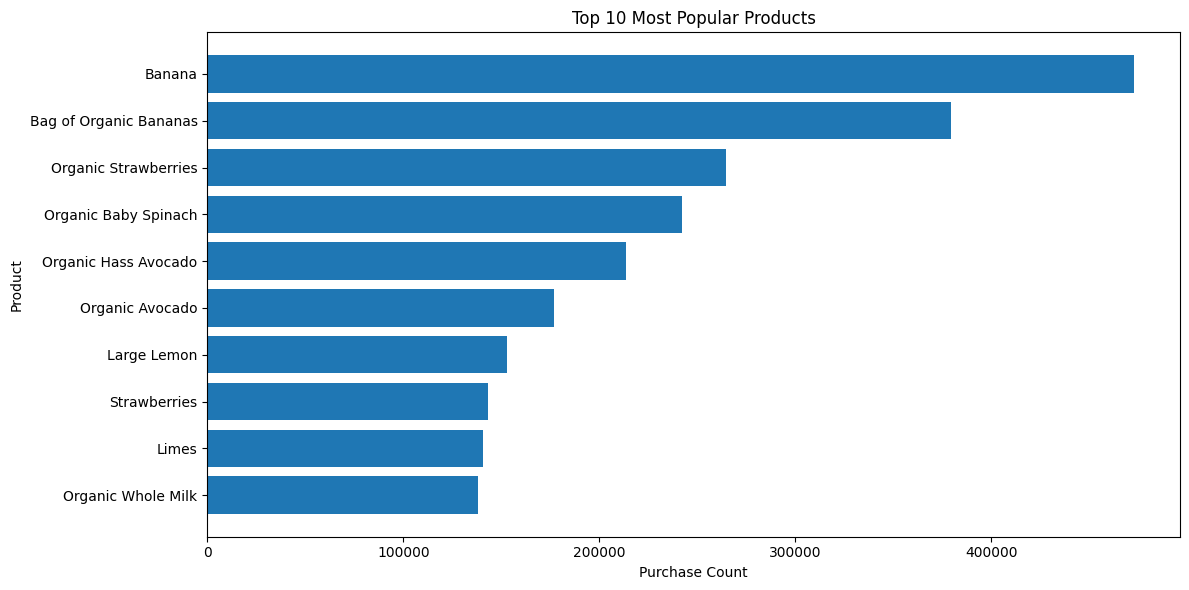

In [ ]:
# ============================================================
# STEP 5 - PRODUCT POPULARITY ANALYSIS
# ============================================================

product_popularity = (
    df.groupby(
        ["product_id", "product_name"]
    )
    .size()
    .reset_index(name="purchase_count")
    .sort_values(
        "purchase_count",
        ascending=False
    )
)

print("Top 20 Most Popular Products:")

display(product_popularity.head(20))

# Visualization
top_products = product_popularity.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_products["product_name"][::-1],
    top_products["purchase_count"][::-1]
)

plt.xlabel("Purchase Count")
plt.ylabel("Product")
plt.title("Top 10 Most Popular Products")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 6 - REORDER RATE ANALYSIS
# ============================================================

reorder_analysis = (
    df.groupby(
        ["product_id", "product_name"]
    )
    .agg(
        total_purchases=("product_id", "count"),
        reorder_count=("reordered", "sum")
    )
    .reset_index()
)

reorder_analysis["reorder_rate"] = (
    reorder_analysis["reorder_count"]
    / reorder_analysis["total_purchases"]
) * 100

# Consider products purchased at least 100 times
reorder_filtered = reorder_analysis[
    reorder_analysis["total_purchases"] >= 100
].copy()

reorder_filtered = reorder_filtered.sort_values(
    "reorder_rate",
    ascending=False
)

print("Top Products by Reorder Rate:")

display(reorder_filtered.head(20))

Top Products by Reorder Rate:


,product_id,product_name,total_purchases,reorder_count,reorder_rate
27734,27740,Chocolate Love Bar,101,93,92.079208
35598,35604,Maca Buttercups,100,90,90.000000
38243,38251,Benchbreak Chardonnay,111,99,89.189189
10232,10236,Fragrance Free Clay with Natural Odor Eliminat...,129,113,87.596899
20594,20598,Thousand Island Salad Snax,112,98,87.500000
35490,35496,Real2 Alkalized Water 500 ml,451,389,86.252772
9288,9292,Half And Half Ultra Pasteurized,2921,2517,86.169120
45495,45504,Whole Organic Omega 3 Milk,9108,7835,86.023276
43386,43394,Organic Lactose Free Whole Milk,8477,7282,85.903032
5511,5514,Organic Homogenized Whole Milk,3970,3405,85.768262


In [ ]:
# ============================================================
# STEP 7 - CUSTOMER PURCHASING BEHAVIOR
# ============================================================

customer_behavior = (
    df.groupby("user_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_products=("product_id", "count"),
        unique_products=("product_id", "nunique")
    )
    .reset_index()
)

customer_behavior["avg_products_per_order"] = (
    customer_behavior["total_products"]
    / customer_behavior["total_orders"]
)

print("Customer Purchasing Behavior:")

display(customer_behavior.head(20))


# ============================================================
# TOP 20 CUSTOMERS
# ============================================================

top_customers = customer_behavior.sort_values(
    "total_orders",
    ascending=False
)

print("Top 20 Customers by Number of Orders:")

display(top_customers.head(20))

Customer Purchasing Behavior:


,user_id,total_orders,total_products,unique_products,avg_products_per_order
0,1,10,59,18,5.900000
1,2,14,195,102,13.928571
2,3,12,88,33,7.333333
3,4,5,18,17,3.600000
4,5,4,37,23,9.250000
5,6,3,14,12,4.666667
6,7,20,206,68,10.300000
7,8,3,49,36,16.333333
8,9,3,76,58,25.333333
9,10,5,143,94,28.600000


Top 20 Customers by Number of Orders:


,user_id,total_orders,total_products,unique_products,avg_products_per_order
75123,75124,99,1622,56,16.383838
173430,173431,99,1274,304,12.868687
127157,127158,99,1885,280,19.040404
96191,96192,99,604,152,6.101010
173072,173073,99,1021,156,10.313131
172965,172966,99,674,152,6.808081
18997,18998,99,239,63,2.414141
62865,62866,99,1298,341,13.111111
62889,62890,99,905,189,9.141414
96496,96497,99,840,239,8.484848


Department Performance:


,department_id,department,total_purchases
3,4,produce,9479291
15,16,dairy eggs,5414016
18,19,snacks,2887550
6,7,beverages,2690129
0,1,frozen,2236432


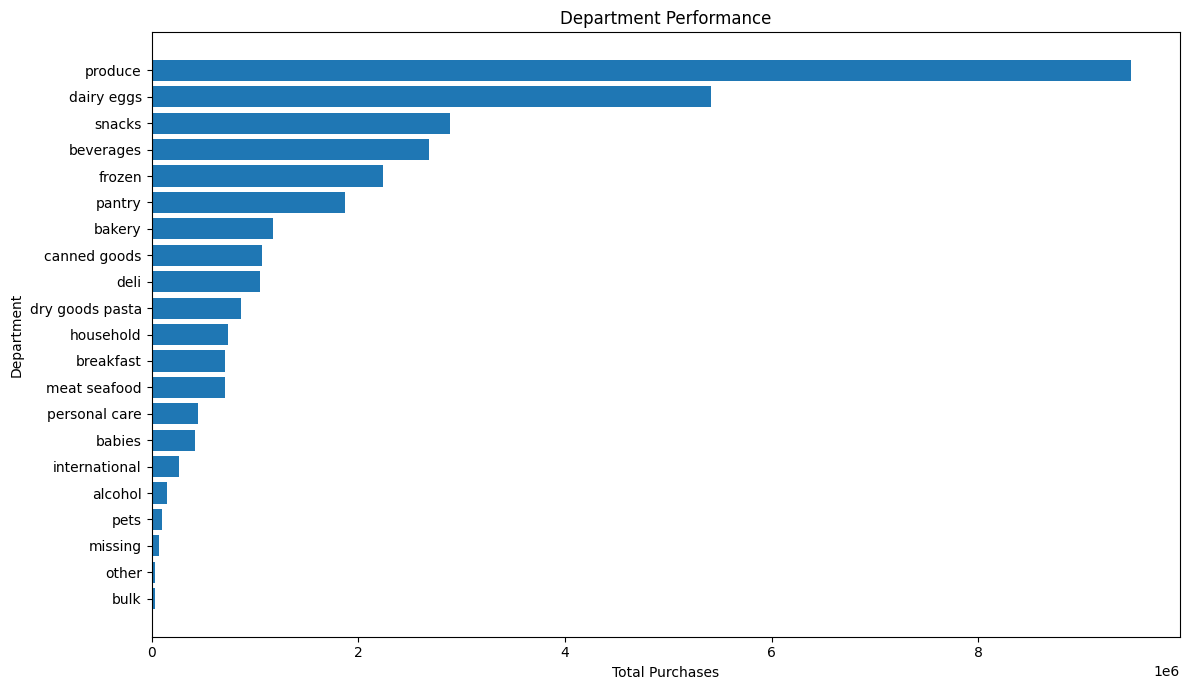

In [ ]:
department_performance = (
    df.groupby(
        ["department_id", "department"]
    )
    .size()
    .reset_index(name="total_purchases")
    .sort_values(
        "total_purchases",
        ascending=False
    )
)

print("Department Performance:")
display(department_performance.head())


plt.figure(figsize=(12, 7))

plt.barh(
    department_performance["department"][::-1],
    department_performance["total_purchases"][::-1]
)

plt.xlabel("Total Purchases")
plt.ylabel("Department")
plt.title("Department Performance")

plt.tight_layout()
plt.show()

Basket Size Statistics:
count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: basket_size, dtype: float64

Average Basket Size: 10.09 products/order


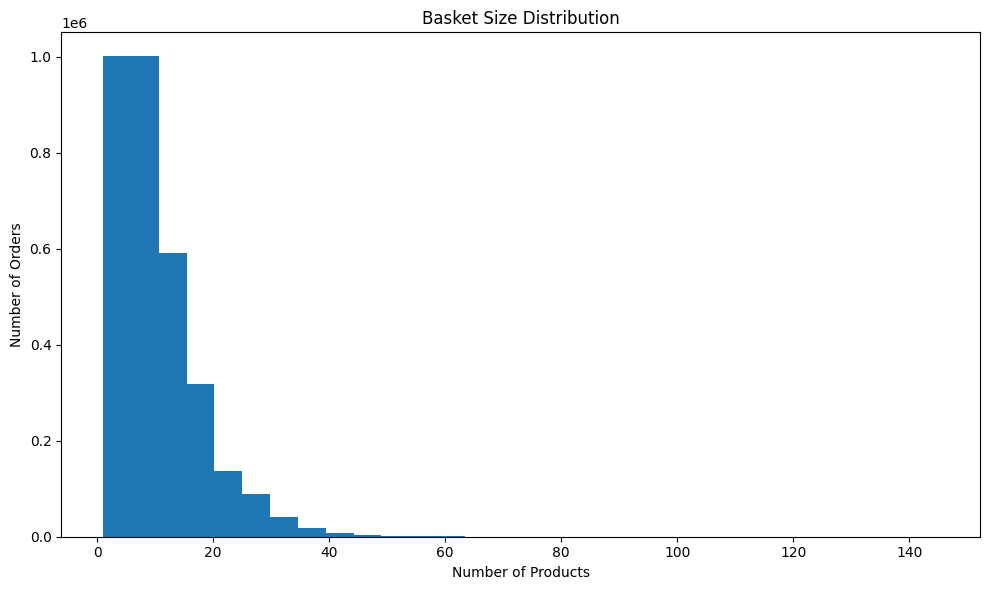

In [ ]:
# ============================================================
# STEP 8 - BASKET SIZE ANALYSIS
# ============================================================

basket_size = (
    df.groupby("order_id")
    .size()
    .reset_index(name="basket_size")
)

print("Basket Size Statistics:")

print(basket_size["basket_size"].describe())

average_basket_size = basket_size["basket_size"].mean()

print(
    f"\nAverage Basket Size: "
    f"{average_basket_size:.2f} products/order"
)

# Visualization
plt.figure(figsize=(10, 6))

plt.hist(
    basket_size["basket_size"],
    bins=30
)

plt.xlabel("Number of Products")
plt.ylabel("Number of Orders")
plt.title("Basket Size Distribution")

plt.tight_layout()
plt.show()

,department_id,department,total_purchases,unique_products,unique_customers,unique_orders,reorder_count,reorder_rate
3,4,produce,9479291,1684,193237,2409320,6160710,64.991253
15,16,dairy eggs,5414016,3448,190565,2177338,3627221,66.996865
18,19,snacks,2887550,6263,174219,1391447,1657973,57.417984
6,7,beverages,2690129,4363,172795,1457351,1757892,65.346011
0,1,frozen,2236432,4007,163233,1181018,1211890,54.188547
12,13,pantry,1875577,5370,172755,1117892,650301,34.672050
2,3,bakery,1176787,1516,140612,881556,739188,62.814086
14,15,canned goods,1068058,2092,133733,681305,488535,45.740493
19,20,deli,1051249,1322,133865,770300,638864,60.771901
8,9,dry goods pasta,866627,1858,124820,597862,399581,46.107610


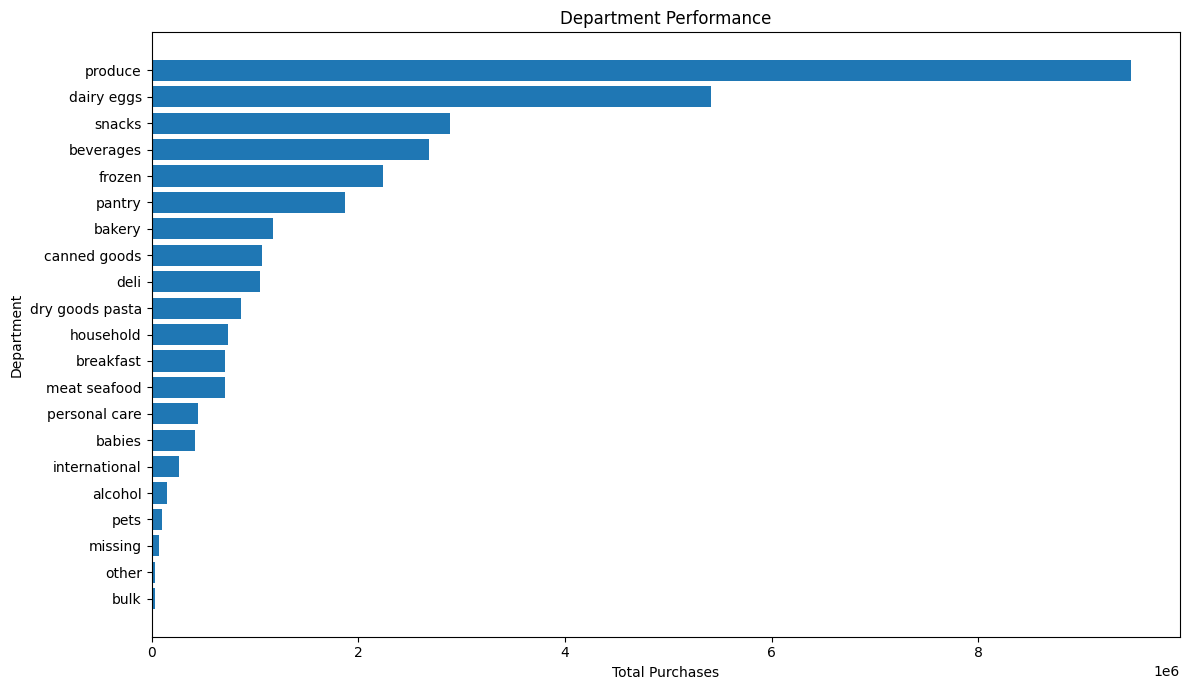

In [ ]:
# ============================================================
# STEP 9 - DEPARTMENT PERFORMANCE
# ============================================================

department_performance = (
    df.groupby(
        ["department_id", "department"]
    )
    .agg(
        total_purchases=("product_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_customers=("user_id", "nunique"),
        unique_orders=("order_id", "nunique"),
        reorder_count=("reordered", "sum")
    )
    .reset_index()
)

department_performance["reorder_rate"] = (
    department_performance["reorder_count"]
    / department_performance["total_purchases"]
) * 100

department_performance = department_performance.sort_values(
    "total_purchases",
    ascending=False
)

display(department_performance)

# Visualization
plt.figure(figsize=(12, 7))

plt.barh(
    department_performance["department"][::-1],
    department_performance["total_purchases"][::-1]
)

plt.xlabel("Total Purchases")
plt.ylabel("Department")
plt.title("Department Performance")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 10 - FREQUENTLY REORDERED PRODUCTS
# ============================================================

frequently_reordered = (
    df.groupby(
        ["product_id", "product_name"]
    )
    .agg(
        total_purchases=("product_id", "count"),
        reorder_count=("reordered", "sum")
    )
    .reset_index()
)

frequently_reordered["reorder_rate"] = (
    frequently_reordered["reorder_count"]
    / frequently_reordered["total_purchases"]
) * 100

frequently_reordered = frequently_reordered.sort_values(
    "reorder_count",
    ascending=False
)

print("Top 20 Frequently Reordered Products:")

display(frequently_reordered.head(20))

Top 20 Frequently Reordered Products:


,product_id,product_name,total_purchases,reorder_count,reorder_rate
24848,24852,Banana,472565,398609,84.350089
13172,13176,Bag of Organic Bananas,379450,315913,83.255501
21133,21137,Organic Strawberries,264683,205845,77.770389
21899,21903,Organic Baby Spinach,241921,186884,77.250011
47198,47209,Organic Hass Avocado,213584,170131,79.655311
47755,47766,Organic Avocado,176815,134044,75.810310
27839,27845,Organic Whole Milk,137905,114510,83.035423
47615,47626,Large Lemon,152657,106255,69.603752
27960,27966,Organic Raspberries,137057,105409,76.908877
16793,16797,Strawberries,142951,99802,69.815531


In [ ]:
# ============================================================
# STEP 11 - PRODUCT SEGMENTATION
# ============================================================

product_segments = (
    df.groupby(
        ["product_id", "product_name"]
    )
    .agg(
        purchase_count=("product_id", "count"),
        reorder_count=("reordered", "sum")
    )
    .reset_index()
)

product_segments["reorder_rate"] = (
    product_segments["reorder_count"]
    / product_segments["purchase_count"]
) * 100

# Median thresholds
popularity_threshold = (
    product_segments["purchase_count"].median()
)

reorder_threshold = (
    product_segments["reorder_rate"].median()
)

print("Popularity Threshold:", popularity_threshold)
print("Reorder Rate Threshold:", reorder_threshold)


def classify_product(row):

    high_popularity = (
        row["purchase_count"] >= popularity_threshold
    )

    high_reorder = (
        row["reorder_rate"] >= reorder_threshold
    )

    if high_popularity and high_reorder:
        return "High Popularity - High Reorder"

    elif high_popularity and not high_reorder:
        return "High Popularity - Low Reorder"

    elif not high_popularity and high_reorder:
        return "Low Popularity - High Reorder"

    else:
        return "Low Popularity - Low Reorder"


product_segments["segment"] = (
    product_segments.apply(
        classify_product,
        axis=1
    )
)

display(product_segments.head(20))

Popularity Threshold: 60.0
Reorder Rate Threshold: 37.66233766233766


,product_id,product_name,purchase_count,reorder_count,reorder_rate,segment
0,1,Chocolate Sandwich Cookies,1852,1136,61.339093,High Popularity - High Reorder
1,2,All-Seasons Salt,90,12,13.333333,High Popularity - Low Reorder
2,3,Robust Golden Unsweetened Oolong Tea,277,203,73.285199,High Popularity - High Reorder
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,329,147,44.680851,High Popularity - High Reorder
4,5,Green Chile Anytime Sauce,15,9,60.000000,Low Popularity - High Reorder
5,6,Dry Nose Oil,8,3,37.500000,Low Popularity - Low Reorder
6,7,Pure Coconut Water With Orange,30,12,40.000000,Low Popularity - High Reorder
7,8,Cut Russet Potatoes Steam N' Mash,165,83,50.303030,High Popularity - High Reorder
8,9,Light Strawberry Blueberry Yogurt,156,82,52.564103,High Popularity - High Reorder
9,10,Sparkling Orange Juice & Prickly Pear Beverage,2572,1304,50.699844,High Popularity - High Reorder


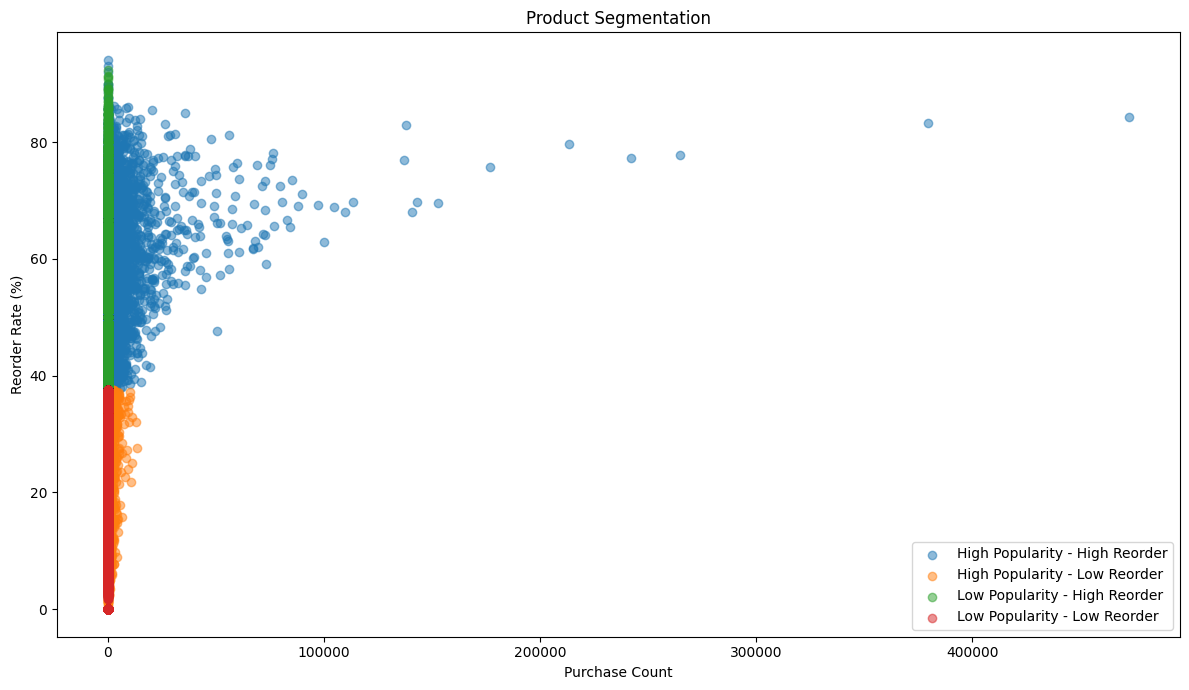

In [ ]:
# ============================================================
# STEP 12 - PRODUCT SEGMENT VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 7))

for segment in product_segments["segment"].unique():

    segment_data = product_segments[
        product_segments["segment"] == segment
    ]

    plt.scatter(
        segment_data["purchase_count"],
        segment_data["reorder_rate"],
        label=segment,
        alpha=0.5
    )

plt.xlabel("Purchase Count")
plt.ylabel("Reorder Rate (%)")
plt.title("Product Segmentation")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 13 - FINAL PRODUCT ANALYTICS DATASET
# ============================================================

final_product_analysis = product_segments.merge(
    products[
        [
            "product_id",
            "aisle_id",
            "department_id"
        ]
    ],
    on="product_id",
    how="left"
)

final_product_analysis = final_product_analysis.merge(
    departments[
        [
            "department_id",
            "department"
        ]
    ],
    on="department_id",
    how="left"
)

final_product_analysis = final_product_analysis[
    [
        "product_id",
        "product_name",
        "aisle_id",
        "department_id",
        "department",
        "purchase_count",
        "reorder_count",
        "reorder_rate",
        "segment"
    ]
]

final_product_analysis = final_product_analysis.sort_values(
    "purchase_count",
    ascending=False
)

print("Final Dataset Shape:", final_product_analysis.shape)

display(final_product_analysis.head(20))

Final Dataset Shape: (49677, 9)


,product_id,product_name,aisle_id,department_id,department,purchase_count,reorder_count,reorder_rate,segment
24848,24852,Banana,24,4,produce,472565,398609,84.350089,High Popularity - High Reorder
13172,13176,Bag of Organic Bananas,24,4,produce,379450,315913,83.255501,High Popularity - High Reorder
21133,21137,Organic Strawberries,24,4,produce,264683,205845,77.770389,High Popularity - High Reorder
21899,21903,Organic Baby Spinach,123,4,produce,241921,186884,77.250011,High Popularity - High Reorder
47198,47209,Organic Hass Avocado,24,4,produce,213584,170131,79.655311,High Popularity - High Reorder
47755,47766,Organic Avocado,24,4,produce,176815,134044,75.810310,High Popularity - High Reorder
47615,47626,Large Lemon,24,4,produce,152657,106255,69.603752,High Popularity - High Reorder
16793,16797,Strawberries,24,4,produce,142951,99802,69.815531,High Popularity - High Reorder
26204,26209,Limes,24,4,produce,140627,95768,68.100720,High Popularity - High Reorder
27839,27845,Organic Whole Milk,84,16,dairy eggs,137905,114510,83.035423,High Popularity - High Reorder


In [ ]:
# ============================================================
# STEP 14 - BUSINESS INSIGHTS & RECOMMENDATIONS
# ============================================================

# Top product
top_product = product_popularity.iloc[0]

# Top department
top_department = department_performance.iloc[0]

# Highest reorder product with minimum purchase condition
top_reorder_product = reorder_filtered.iloc[0]

# Average basket
avg_basket = basket_size["basket_size"].mean()

# Overall reorder rate
overall_reorder_rate = df["reordered"].mean() * 100

print("=" * 60)
print("INSTACART BUSINESS INSIGHTS")
print("=" * 60)

print(
    f"\n1. Most Popular Product:"
    f"\n   {top_product['product_name']}"
    f" ({top_product['purchase_count']:,} purchases)"
)

print(
    f"\n2. Top Performing Department:"
    f"\n   {top_department['department']}"
    f" ({top_department['total_purchases']:,} purchases)"
)

print(
    f"\n3. Highest Reorder Rate Product:"
    f"\n   {top_reorder_product['product_name']}"
    f" ({top_reorder_product['reorder_rate']:.2f}%)"
)

print(
    f"\n4. Average Basket Size:"
    f"\n   {avg_basket:.2f} products/order"
)

print(
    f"\n5. Overall Reorder Rate:"
    f"\n   {overall_reorder_rate:.2f}%"
)

print("\n6. Product Segment Distribution:")

segment_counts = (
    product_segments["segment"]
    .value_counts()
)

print(segment_counts)

print("\n7. Business Recommendations:")

print("""
- Maintain strong availability for highly popular products.
- Prioritize high-popularity and high-reorder products.
- Use reorder behavior to support repeat-purchase campaigns.
- Monitor low-popularity and low-reorder products for optimization.
- Analyze high-reorder products for customer retention strategies.
- Use department performance to optimize inventory and promotions.
- Use basket-size patterns for cross-selling and product recommendations.
""")

INSTACART BUSINESS INSIGHTS

1. Most Popular Product:
   Banana (472,565 purchases)

2. Top Performing Department:
   produce (9,479,291 purchases)

3. Highest Reorder Rate Product:
   Chocolate Love Bar (92.08%)

4. Average Basket Size:
   10.09 products/order

5. Overall Reorder Rate:
   58.97%

6. Product Segment Distribution:
segment
High Popularity - High Reorder    17719
Low Popularity - Low Reorder      17697
High Popularity - Low Reorder      7141
Low Popularity - High Reorder      7120
Name: count, dtype: int64

7. Business Recommendations:

- Maintain strong availability for highly popular products.
- Prioritize high-popularity and high-reorder products.
- Use reorder behavior to support repeat-purchase campaigns.
- Monitor low-popularity and low-reorder products for optimization.
- Analyze high-reorder products for customer retention strategies.
- Use department performance to optimize inventory and promotions.
- Use basket-size patterns for cross-selling and product recomme

UNIFIED KPI

In [ ]:
# ============================================================
# LOAD ALL 4 DATASETS
# ============================================================

import pandas as pd
import os
import glob

# ============================================================
# 1. WALMART
# ============================================================

walmart_path = "./data/walmart"

walmart_files = glob.glob(
    os.path.join(walmart_path, "**", "*.csv"),
    recursive=True
)

print("Walmart files:", walmart_files)

walmart = pd.read_csv(walmart_files[0])

print("Walmart:", walmart.shape)


# ============================================================
# 2. ROSSMANN
# ============================================================

rossmann_path = "./data/rossmann"

rossmann_train = glob.glob(
    os.path.join(rossmann_path, "**", "train.csv"),
    recursive=True
)

print("\nRossmann files:", rossmann_train)

rossmann = pd.read_csv(rossmann_train[0])

print("Rossmann:", rossmann.shape)


# ============================================================
# 3. INSTACART
# ============================================================

instacart_path = "./data/instacart"

instacart_files = glob.glob(
    os.path.join(instacart_path, "**", "*.csv"),
    recursive=True
)

print("\nInstacart files:")
for f in instacart_files:
    print(" -", f)


# Find required files
def get_file(filename):
    for f in instacart_files:
        if os.path.basename(f).lower() == filename.lower():
            return f
    raise FileNotFoundError(filename)


orders = pd.read_csv(
    get_file("orders.csv")
)

prior = pd.read_csv(
    get_file("order_products__prior.csv")
)

products = pd.read_csv(
    get_file("products.csv")
)

# Merge
instacart = (
    prior
    .merge(
        orders,
        on="order_id",
        how="left"
    )
    .merge(
        products,
        on="product_id",
        how="left"
    )
)

print("Instacart:", instacart.shape)


# ============================================================
# 4. SUPPLY CHAIN
# ============================================================

supply_chain_path = "./data/supply_chain"

supply_files = glob.glob(
    os.path.join(
        supply_chain_path,
        "**",
        "*.csv"
    ),
    recursive=True
)

print("\nSupply Chain files:")
for f in supply_files:
    print(" -", f)


if len(supply_files) > 0:

    # Load first CSV
    supply_chain = pd.read_csv(
        supply_files[0]
    )

    print("Supply Chain:", supply_chain.shape)

else:

    print(
        "\nWARNING: Supply Chain CSV was not found."
    )

    print(
        "Download/extract the Supply Chain dataset "
        "into ./data/supply_chain"
    )


# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "=" * 60)
print("DATASET STATUS")
print("=" * 60)

print("Walmart      :", "walmart" in globals())
print("Rossmann     :", "rossmann" in globals())
print("Instacart    :", "instacart" in globals())
print("Supply Chain :", "supply_chain" in globals())

Walmart files: ['./data/walmart/Walmart_Store_sales.csv']
Walmart: (6435, 8)

Rossmann files: ['./data/rossmann/train.csv']


/tmp/ipykernel_57781/2163322517.py:40: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  rossmann = pd.read_csv(rossmann_train[0])


Rossmann: (1017209, 9)

Instacart files:
 - ./data/instacart/aisles.csv
 - ./data/instacart/orders.csv
 - ./data/instacart/order_products__train.csv
 - ./data/instacart/products.csv
 - ./data/instacart/order_products__prior.csv
 - ./data/instacart/departments.csv
 - ./data/instacart/output/reorder_recommendations.csv
 - ./data/instacart/output/stockout_risk.csv
 - ./data/instacart/output/inventory_optimization.csv


In [ ]:
# ============================================================
# CHECK ZIP CONTENT
# ============================================================

import zipfile

zip_file = "high-dimensional-supply-chain-inventory-dataset.zip"

with zipfile.ZipFile(zip_file, "r") as z:
    print("Files inside ZIP:\n")
    for file in z.namelist():
        print(file)

Files inside ZIP:

supply_chain_dataset1.csv


In [ ]:
# ============================================================
# MASTER CELL
# LOAD DATASETS + CREATE UNIFIED KPI TABLE
# ============================================================

import pandas as pd
import numpy as np
import os
import glob

# ============================================================
# 1. WALMART
# ============================================================

walmart_files = glob.glob(
    "./data/walmart/**/*.csv",
    recursive=True
)

print("Walmart files:", walmart_files)

if not walmart_files:
    raise FileNotFoundError(
        "Walmart CSV not found in ./data/walmart"
    )

# Prefer train.csv if available, otherwise first CSV
walmart_file = next(
    (f for f in walmart_files
     if "train" in os.path.basename(f).lower()),
    walmart_files[0]
)

walmart = pd.read_csv(walmart_file)

print("Walmart loaded:", walmart.shape)


# ============================================================
# 2. ROSSMANN
# ============================================================

rossmann_files = glob.glob(
    "./data/rossmann/**/*.csv",
    recursive=True
)

print("Rossmann files:", rossmann_files)

if not rossmann_files:
    raise FileNotFoundError(
        "Rossmann CSV not found in ./data/rossmann"
    )

rossmann_file = next(
    (f for f in rossmann_files
     if os.path.basename(f).lower() == "train.csv"),
    rossmann_files[0]
)

rossmann = pd.read_csv(rossmann_file)

print("Rossmann loaded:", rossmann.shape)


# ============================================================
# 3. INSTACART
# ============================================================

instacart_files = glob.glob(
    "./data/instacart/**/*.csv",
    recursive=True
)

print("Instacart files:", instacart_files)

def find_instacart_file(filename):

    for f in instacart_files:
        if os.path.basename(f).lower() == filename.lower():
            return f

    raise FileNotFoundError(
        f"{filename} not found in ./data/instacart"
    )


orders = pd.read_csv(
    find_instacart_file("orders.csv")
)

prior = pd.read_csv(
    find_instacart_file("order_products__prior.csv")
)

products = pd.read_csv(
    find_instacart_file("products.csv")
)

instacart = (
    prior
    .merge(
        orders,
        on="order_id",
        how="left"
    )
    .merge(
        products,
        on="product_id",
        how="left"
    )
)

print("Instacart loaded:", instacart.shape)


# ============================================================
# 4. SUPPLY CHAIN
# ============================================================

supply_files = glob.glob(
    "./data/supply_chainn/**/*.csv",
    recursive=True
)

print("Supply Chain files:", supply_files)

if not supply_files:

    # Also check normal spelling
    supply_files = glob.glob(
        "./data/supply_chain/**/*.csv",
        recursive=True
    )

if not supply_files:
    raise FileNotFoundError(
        "Supply Chain CSV not found. "
        "Check ./data/supply_chainn"
    )

supply_file = supply_files[0]

supply_chain = pd.read_csv(supply_file)

print("Supply Chain loaded:", supply_chain.shape)


# ============================================================
# 5. VERIFY ALL DATASETS
# ============================================================

print("\n" + "=" * 70)
print("ALL DATASETS LOADED")
print("=" * 70)

print("Walmart      :", walmart.shape)
print("Rossmann     :", rossmann.shape)
print("Supply Chain :", supply_chain.shape)
print("Instacart    :", instacart.shape)


# ============================================================
# 6. UNIFIED KPI TABLE
# ============================================================

kpis = []


# ------------------------------------------------------------
# WALMART
# ------------------------------------------------------------

if "Weekly_Sales" in walmart.columns:

    kpis.extend([
        ["Walmart", "Total Sales",
         walmart["Weekly_Sales"].sum()],

        ["Walmart", "Average Weekly Sales",
         walmart["Weekly_Sales"].mean()],

        ["Walmart", "Maximum Weekly Sales",
         walmart["Weekly_Sales"].max()],

        ["Walmart", "Minimum Weekly Sales",
         walmart["Weekly_Sales"].min()]
    ])

if "Store" in walmart.columns:

    kpis.append([
        "Walmart",
        "Number of Stores",
        walmart["Store"].nunique()
    ])

kpis.append([
    "Walmart",
    "Total Records",
    len(walmart)
])


# ------------------------------------------------------------
# ROSSMANN
# ------------------------------------------------------------

if "Sales" in rossmann.columns:

    kpis.extend([
        ["Rossmann", "Total Sales",
         rossmann["Sales"].sum()],

        ["Rossmann", "Average Sales",
         rossmann["Sales"].mean()],

        ["Rossmann", "Maximum Sales",
         rossmann["Sales"].max()],

        ["Rossmann", "Minimum Sales",
         rossmann["Sales"].min()]
    ])

if "Customers" in rossmann.columns:

    kpis.extend([
        ["Rossmann", "Total Customers",
         rossmann["Customers"].sum()],

        ["Rossmann", "Average Customers",
         rossmann["Customers"].mean()]
    ])

if "Store" in rossmann.columns:

    kpis.append([
        "Rossmann",
        "Number of Stores",
        rossmann["Store"].nunique()
    ])

if "Promo" in rossmann.columns:

    kpis.extend([
        ["Rossmann", "Promotion Days",
         (rossmann["Promo"] == 1).sum()],

        ["Rossmann", "Non-Promotion Days",
         (rossmann["Promo"] == 0).sum()]
    ])

kpis.append([
    "Rossmann",
    "Total Records",
    len(rossmann)
])


# ------------------------------------------------------------
# SUPPLY CHAIN
# ------------------------------------------------------------

kpis.append([
    "Supply Chain",
    "Total Records",
    len(supply_chain)
])

# Show numeric columns
supply_numeric = supply_chain.select_dtypes(
    include=np.number
).columns.tolist()

print("\nSupply Chain numeric columns:")
print(supply_numeric)

# Add average for useful numeric fields
for col in supply_numeric:

    kpis.append([
        "Supply Chain",
        f"Average {col}",
        supply_chain[col].mean()
    ])


# ------------------------------------------------------------
# INSTACART
# ------------------------------------------------------------

total_orders = instacart["order_id"].nunique()

total_customers = instacart["user_id"].nunique()

total_products = instacart["product_id"].nunique()

total_items = len(instacart)

kpis.extend([
    ["Instacart", "Total Orders",
     total_orders],

    ["Instacart", "Total Customers",
     total_customers],

    ["Instacart", "Total Products",
     total_products],

    ["Instacart", "Total Items",
     total_items],

    ["Instacart", "Average Basket Size",
     total_items / total_orders],

    ["Instacart", "Reordered Items",
     instacart["reordered"].sum()],

    ["Instacart", "Reorder Rate (%)",
     instacart["reordered"].mean() * 100]
])


# ============================================================
# FINAL UNIFIED TABLE
# ============================================================

unified_kpis = pd.DataFrame(
    kpis,
    columns=[
        "Dataset",
        "KPI",
        "Value"
    ]
)

unified_kpis["Value"] = pd.to_numeric(
    unified_kpis["Value"],
    errors="coerce"
).round(2)


print("\n" + "=" * 70)
print("UNIFIED KPI TABLE")
print("=" * 70)

display(unified_kpis)

Walmart files: ['./data/walmart/Walmart_Store_sales.csv']
Walmart loaded: (6435, 8)
Rossmann files: ['./data/rossmann/train.csv', './data/rossmann/test.csv', './data/rossmann/store.csv']


/tmp/ipykernel_58812/3673701351.py:61: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  rossmann = pd.read_csv(rossmann_file)


Rossmann loaded: (1017209, 9)
Instacart files: ['./data/instacart/aisles.csv', './data/instacart/orders.csv', './data/instacart/order_products__train.csv', './data/instacart/products.csv', './data/instacart/order_products__prior.csv', './data/instacart/departments.csv', './data/instacart/output/reorder_recommendations.csv', './data/instacart/output/stockout_risk.csv', './data/instacart/output/inventory_optimization.csv']
Instacart loaded: (32434489, 13)
Supply Chain files: []
Supply Chain loaded: (91250, 15)

ALL DATASETS LOADED
Walmart      : (6435, 8)
Rossmann     : (1017209, 9)
Supply Chain : (91250, 15)
Instacart    : (32434489, 13)

Supply Chain numeric columns:
['Units_Sold', 'Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag', 'Stockout_Flag', 'Demand_Forecast']

UNIFIED KPI TABLE


,Dataset,KPI,Value
0,Walmart,Total Sales,6.737219e+09
1,Walmart,Average Weekly Sales,1.046965e+06
2,Walmart,Maximum Weekly Sales,3.818686e+06
3,Walmart,Minimum Weekly Sales,2.099862e+05
4,Walmart,Number of Stores,4.500000e+01
5,Walmart,Total Records,6.435000e+03
6,Rossmann,Total Sales,5.873181e+09
7,Rossmann,Average Sales,5.773820e+03
8,Rossmann,Maximum Sales,4.155100e+04
9,Rossmann,Minimum Sales,0.000000e+00


In [ ]:
# ============================================================
# EXPORT UNIFIED KPI TABLE FOR POWER BI
# ============================================================

unified_kpis.to_csv(
    "unified_kpis.csv",
    index=False
)

print("File created successfully: unified_kpis.csv")

File created successfully: unified_kpis.csv


In [ ]:
from google.colab import files

files.download("unified_kpis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>